# Final Conditioned Pipeline Evaluation (LOCAL)

This notebook evaluates the **GNN + conditioned EBM + LP** pipeline on the
three criticality families used in the paper.

It is tailored to the conditioned EBM trained in `final_ebm_train.ipynb`,
where the EBM receives both:
- the frozen HTE zone embeddings
- normalized global scenario descriptors (`n_zones`, `criticality_index`,
  `peak_to_valley_ratio`, `vre_share_mean`, etc.)

The notebook tests the two central hypotheses of the paper:

1. **Compute-bounded exploration**:
   the best-of-`K` cost gap decreases as the sampled candidate pool grows.
2. **Scaling with criticality**:
   the pipeline speedup relative to MILP is positively correlated with the
   scenario criticality index.

It is inspired by `evaluation_pipeline_local.ipynb` but focused on these
two claims and adapted to the final conditioned EBM checkpoint.

## 1. Verify Local Environment

In [1]:
import os, sys, json, math, time, pickle, shutil, logging
from dataclasses import asdict, replace
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from scipy import stats

REPO_PATH = Path(r"C:\Users\coudr\OneDrive\projects\benchmark\benchmark_milp_gnn")
assert REPO_PATH.exists(), REPO_PATH

if str(REPO_PATH) not in sys.path:
    sys.path.insert(0, str(REPO_PATH))
if str(REPO_PATH / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_PATH / 'src'))

torch.set_float32_matmul_precision('high')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Python: {sys.version.split()[0]}")
print(f"Torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Python: 3.11.9
Torch: 2.5.1+cu124
CUDA available: True
Device: cuda
CUDA device: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA memory: 6.00 GB


## 2. Setup Imports and Paths

In [2]:
# Clear cached repo modules so reruns pick up local source edits.
for module_name in [m for m in list(sys.modules) if m.startswith('src.')]:
    del sys.modules[module_name]

from src.analysis.criticality_index import compute_criticality
from src.ebm.model_v3 import TrajectoryZonalEBM
from src.eval.advanced_analysis import (
    PHYSICAL_FEATURE_COLUMNS,
    apply_candidate_selector,
    build_candidate_pool_frame,
    build_physical_complexity_frame,
    build_sampler_sweep_configs,
    compute_best_of_k_curve,
    compute_k_sampling_diagnostics,
    compute_solution_diversity_frame,
    compute_top_m_policy_curve,
    extract_physical_complexity_features,
    fit_candidate_selector,
    fit_physical_feature_robustness,
    fit_scaling_law_models,
    load_candidate_selector,
    merge_physical_complexity_features,
    save_candidate_selector,
    summarize_speedup_operating_modes,
)
from src.eval.metrics import (
    compute_eval_metrics,
    compute_percentile_metrics,
    format_metrics_table,
)
from src.eval.pipeline_runner import (
    PipelineConfig,
    PipelineResult,
    PipelineRunner,
    _binary_stats,
    _deepest_stage_reached,
    _diagnostic_result_key,
    _pairwise_hamming_stats,
)
from src.milp.scenario_loader import load_scenario_data
from src.milp.solve import solve_scenario

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
sns.set_context('talk', font_scale=0.85)

FAMILY_COLORS = {
    'low': '#2ecc71',
    'medium': '#f1c40f',
    'high': '#e74c3c',
}
STAGE_BASE_COLORS = {
    'hard_fix': '#2ecc71',
    'repair_stage_1': '#f1c40f',
    'repair_stage_2': '#e67e22',
    'full_soft': '#e74c3c',
    'round_refix': '#9b59b6',
}

## 3. Configuration

In [3]:
EXPERIMENT_NAME = 'final_ebm_conditioned_film'
OUTPUT_DIR = REPO_PATH / 'outputs' / 'pipeline_eval_final_conditioned'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONDITIONED_EBM_PATH = REPO_PATH / 'outputs' / 'ebm_models' / EXPERIMENT_NAME / 'final_conditioned_ebm.pt'
PIPELINE_RESULTS_PATH = OUTPUT_DIR / 'pipeline_eval_all_families_exact_projection.pkl'
PIPELINE_K1_RESULTS_PATH = OUTPUT_DIR / 'pipeline_eval_all_families_k1_exact_projection.pkl'
CANDIDATE_SELECTOR_PATH = OUTPUT_DIR / 'candidate_selector.pkl'
SAMPLER_SWEEP_DIR = OUTPUT_DIR / 'high_criticality_sampler_sweep'
GRAPH_CACHE_ROOT = OUTPUT_DIR / 'graphs'

RUN_PIPELINE = True
RUN_K1_EVALUATION = True
RUN_LIVE_TOP_M_EVALUATION = True
RUN_HIGH_CRIT_SAMPLER_SWEEP = True
CLEAR_GRAPH_CACHE = False
MAX_SCENARIOS_PER_FAMILY = 10
MAX_SWEEP_SCENARIOS = 10

LIVE_TOP_M = 3
LIVE_TOP_M_SCORE_MODE = 'learned_selector'
LIVE_TOP_M_TARGET_ACTIVATION_RATE = None
LIVE_TOP_M_ENERGY_WEIGHT = 1.0
LIVE_TOP_M_ACTIVATION_WEIGHT = 1.0
LIVE_TOP_M_CACHE_STEM = f"pipeline_eval_all_families_top_m_live_m{LIVE_TOP_M}_{LIVE_TOP_M_SCORE_MODE}"
PIPELINE_TOP_M_RESULTS_PATH = OUTPUT_DIR / f'{LIVE_TOP_M_CACHE_STEM}.pkl'

HEURISTIC_FILES = {
    'low': REPO_PATH / 'outputs' / 'rhmo_low.json',
    'medium': REPO_PATH / 'outputs' / 'rhmo_medium.json',
    'high': REPO_PATH / 'outputs' / 'rhmo_high.json',
}

FAMILIES = {
    'low': {
        'scenarios_dir': REPO_PATH / 'outputs' / 'low_criticality_scenarios',
        'reports_dir': REPO_PATH / 'outputs' / 'low_criticality_scenarios' / 'reports',
    },
    'medium': {
        'scenarios_dir': REPO_PATH / 'outputs' / 'medium_criticality_scenarios',
        'reports_dir': REPO_PATH / 'outputs' / 'medium_criticality_scenarios' / 'reports',
    },
    'high': {
        'scenarios_dir': REPO_PATH / 'outputs' / 'high_criticality_scenarios',
        'reports_dir': REPO_PATH / 'outputs' / 'high_criticality_scenarios' / 'reports',
    },
}

assert CONDITIONED_EBM_PATH.exists(), CONDITIONED_EBM_PATH
CHECKPOINT_META = torch.load(CONDITIONED_EBM_PATH, map_location='cpu', weights_only=False)

print(f"Conditioned EBM checkpoint: {CONDITIONED_EBM_PATH}")
print(f"Model kind: {CHECKPOINT_META.get('model_kind')}")
print(f"Conditioning mode: {CHECKPOINT_META.get('conditioning_mode')}")
print(f"Scenario feature names: {CHECKPOINT_META.get('scenario_feature_names')}")
print(f"Checkpoint config: {CHECKPOINT_META.get('config', {})}")
print(f"Existing cached K=10 results: {PIPELINE_RESULTS_PATH.exists()}")
print(f"Existing cached K=1 results: {PIPELINE_K1_RESULTS_PATH.exists()}")
print(f"Live Top-M cache path: {PIPELINE_TOP_M_RESULTS_PATH}")
print(f"Existing cached live Top-M results: {PIPELINE_TOP_M_RESULTS_PATH.exists()}")
print(f"Existing selector artifact: {CANDIDATE_SELECTOR_PATH.exists()}")

for fam, paths in FAMILIES.items():
    sc_count = len(list(paths['scenarios_dir'].glob('scenario_*.json'))) if paths['scenarios_dir'].exists() else 0
    rp_count = len(list(paths['reports_dir'].glob('scenario_*.json'))) if paths['reports_dir'].exists() else 0
    print(f"  {fam}: {sc_count} scenarios, {rp_count} MILP reports")

Conditioned EBM checkpoint: C:\Users\coudr\OneDrive\projects\benchmark\benchmark_milp_gnn\outputs\ebm_models\final_ebm_conditioned_film\final_conditioned_ebm.pt
Model kind: ScenarioConditionedEBM
Conditioning mode: film
Scenario feature names: ['n_zones', 'criticality_index', 'demand_scale', 'peak_to_valley_ratio', 'vre_share_mean', 'vre_volatility_index', 'storage_adequacy_hours', 'dr_capacity_ratio', 'thermal_capacity_margin', 'nuclear_capacity_margin']
Checkpoint config: {'n_features': 7, 'hidden_dim': 256, 'gru_layers': 3, 'bidirectional': True, 'dropout': 0.1, 'use_peak_term': True, 'peak_tau': 0.5, 'peak_weight': 0.3, 'energy_max': 50.0, 'gold_epochs': 40, 'gold_lr': 2e-05, 'silver_stage1_prefix': 'silver_stage1', 'silver_stage1_overrides': {'silver_lambda_cd': 0.1, 'silver_lambda_pref': 2.0, 'silver_pref_warmup_epochs': 0, 'silver_lp_eval_every': 5, 'silver_lp_scenarios_per_batch': 2, 'silver_lp_candidates_per_scenario': 4, 'silver_lp_max_stages': 4, 'silver_lp_incumbent_candida

## 4. Conditioned EBM Helpers and Runner

In [4]:
def extract_conditioning_features(scenario_path: Path) -> Dict[str, float]:
    scenario_path = Path(scenario_path)
    with scenario_path.open('r', encoding='utf-8') as f:
        scenario_json = json.load(f)

    physical = extract_physical_complexity_features(scenario_path)
    scenario_data = load_scenario_data(scenario_path)

    criticality_value = scenario_json.get('criticality_index', None)
    try:
        criticality_value = float(criticality_value)
    except (TypeError, ValueError):
        criticality_value = float('nan')
    if not np.isfinite(criticality_value):
        criticality_value = float(compute_criticality(scenario_json).criticality_index)

    peak_demand_mw = float(physical['peak_demand_mw'])
    thermal_capacity = float(sum(scenario_data.thermal_capacity.values()))
    nuclear_capacity = float(sum(scenario_data.nuclear_capacity.values()))
    demand_scale = float(
        scenario_json.get('exogenous', {}).get(
            'demand_scale_factor',
            scenario_json.get('meta', {}).get('demand_scale_factor', 1.0),
        )
    )

    return {
        'n_zones': float(physical['n_zones']),
        'criticality_index': criticality_value,
        'demand_scale': demand_scale,
        'peak_to_valley_ratio': float(physical['peak_to_valley_ratio']),
        'vre_share_mean': float(physical['vre_share_mean']),
        'vre_volatility_index': float(physical['vre_volatility_index']),
        'storage_adequacy_hours': float(physical['storage_adequacy_hours']),
        'dr_capacity_ratio': float(physical['dr_capacity_ratio']),
        'thermal_capacity_margin': thermal_capacity / max(peak_demand_mw, 1e-6),
        'nuclear_capacity_margin': nuclear_capacity / max(peak_demand_mw, 1e-6),
    }


def load_conditioned_feature_stats(
    checkpoint_bundle: Dict[str, Any],
    fallback_path: Optional[Path] = None,
) -> Dict[str, Any]:
    payload = checkpoint_bundle.get('scenario_feature_stats')
    if payload is None and fallback_path is not None and Path(fallback_path).exists():
        with Path(fallback_path).open('r', encoding='utf-8') as f:
            payload = json.load(f)
    if payload is None:
        raise ValueError('No scenario feature statistics found in checkpoint or fallback JSON.')

    feature_names = checkpoint_bundle.get('scenario_feature_names') or list(payload.keys())
    mean = np.asarray([float(payload[name]['mean']) for name in feature_names], dtype=np.float32)
    std = np.asarray([float(payload[name]['std']) for name in feature_names], dtype=np.float32)
    std = np.where(std < 1e-6, 1.0, std)
    return {
        'feature_names': list(feature_names),
        'mean': mean,
        'std': std,
        'payload': payload,
    }


STRICT_DIRECT_STAGE = 'hard_fix'
STRICT_REPAIR_STAGE_SLOTS = {'repair_20', 'repair_100'}
STRICT_PROJECTION_STAGES = STRICT_REPAIR_STAGE_SLOTS | {STRICT_DIRECT_STAGE}


def display_stage_name(lp_result: Any, stage_key: str) -> str:
    if stage_key == 'repair_20':
        return str(getattr(lp_result, 'stage_name_repair_20', '') or stage_key)
    if stage_key == 'repair_100':
        return str(getattr(lp_result, 'stage_name_repair_100', '') or stage_key)
    return str(stage_key or '')


def build_stage_color_map(config: PipelineConfig) -> Dict[str, str]:
    return {
        'hard_fix': STAGE_BASE_COLORS['hard_fix'],
        f"repair_{int(config.flip_budget_repair_20)}_flips": STAGE_BASE_COLORS['repair_stage_1'],
        f"repair_{int(config.flip_budget_repair_100)}_flips": STAGE_BASE_COLORS['repair_stage_2'],
        'full_soft': STAGE_BASE_COLORS['full_soft'],
        'round_refix': STAGE_BASE_COLORS['round_refix'],
    }


class ScenarioConditionedEBM(nn.Module):
    def __init__(
        self,
        base_embed_dim: int,
        scenario_dim: int,
        conditioning_mode: str,
        n_features: int,
        hidden_dim: int = 128,
        gru_layers: int = 2,
        bidirectional: bool = True,
        dropout: float = 0.1,
        use_peak_term: bool = True,
        peak_tau: float = 0.5,
        peak_weight: float = 0.3,
        energy_max: float = 50.0,
    ):
        super().__init__()
        self.base_embed_dim = int(base_embed_dim)
        self.scenario_dim = int(scenario_dim)
        self.conditioning_mode = str(conditioning_mode)

        if self.conditioning_mode not in {'film', 'concat'}:
            raise ValueError(f"Unsupported conditioning mode: {self.conditioning_mode}")

        backbone_embed_dim = (
            self.base_embed_dim + self.scenario_dim
            if self.conditioning_mode == 'concat'
            else self.base_embed_dim
        )
        self.backbone = TrajectoryZonalEBM(
            embed_dim=backbone_embed_dim,
            n_features=n_features,
            hidden_dim=hidden_dim,
            gru_layers=gru_layers,
            bidirectional=bidirectional,
            dropout=dropout,
            use_peak_term=use_peak_term,
            peak_tau=peak_tau,
            peak_weight=peak_weight,
            energy_max=energy_max,
        )
        if self.conditioning_mode == 'film':
            self.scenario_mlp = nn.Sequential(
                nn.Linear(self.scenario_dim, hidden_dim),
                nn.SiLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU(),
                nn.Linear(hidden_dim, 2 * self.base_embed_dim),
            )

    def _split_augmented_embedding(self, h_zt: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        expected_dim = self.base_embed_dim + self.scenario_dim
        if h_zt.shape[-1] != expected_dim:
            raise ValueError(f"Expected augmented embedding dim {expected_dim}, got {h_zt.shape[-1]}")
        h_local = h_zt[..., :self.base_embed_dim]
        scenario_vec = h_zt[:, 0, 0, self.base_embed_dim:]
        return h_local, scenario_vec

    def forward(
        self,
        u_zt: torch.Tensor,
        h_zt: torch.Tensor,
        zone_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        if self.scenario_dim == 0:
            return self.backbone(u_zt, h_zt, zone_mask)
        if self.conditioning_mode == 'concat':
            return self.backbone(u_zt, h_zt, zone_mask)

        h_local, scenario_vec = self._split_augmented_embedding(h_zt)
        gamma, beta = self.scenario_mlp(scenario_vec).chunk(2, dim=-1)
        gamma = 1.0 + 0.1 * torch.tanh(gamma)
        beta = 0.1 * torch.tanh(beta)
        h_cond = gamma[:, None, None, :] * h_local + beta[:, None, None, :]
        return self.backbone(u_zt, h_cond, zone_mask)


def build_ebm_from_checkpoint(
    checkpoint_bundle: Dict[str, Any],
    device: str,
) -> nn.Module:
    cfg = checkpoint_bundle.get('config', {})
    state_dict = checkpoint_bundle['model_state_dict'] if 'model_state_dict' in checkpoint_bundle else checkpoint_bundle
    model_kind = checkpoint_bundle.get('model_kind', 'TrajectoryZonalEBM')

    if model_kind == 'ScenarioConditionedEBM':
        model = ScenarioConditionedEBM(
            base_embed_dim=int(checkpoint_bundle.get('base_embed_dim', cfg.get('embed_dim', 128))),
            scenario_dim=int(checkpoint_bundle.get('scenario_feature_dim', len(checkpoint_bundle.get('scenario_feature_names', [])))),
            conditioning_mode=str(checkpoint_bundle.get('conditioning_mode', 'film')),
            n_features=int(cfg.get('n_features', 7)),
            hidden_dim=int(cfg.get('hidden_dim', 128)),
            gru_layers=int(cfg.get('gru_layers', 2)),
            bidirectional=bool(cfg.get('bidirectional', True)),
            dropout=float(cfg.get('dropout', 0.1)),
            use_peak_term=bool(cfg.get('use_peak_term', True)),
            peak_tau=float(cfg.get('peak_tau', 0.5)),
            peak_weight=float(cfg.get('peak_weight', 0.3)),
            energy_max=float(cfg.get('energy_max', 50.0)),
        )
    else:
        model = TrajectoryZonalEBM(
            embed_dim=int(cfg.get('embed_dim', checkpoint_bundle.get('base_embed_dim', 128))),
            n_features=int(cfg.get('n_features', 7)),
            hidden_dim=int(cfg.get('hidden_dim', 128)),
            gru_layers=int(cfg.get('gru_layers', 2)),
            bidirectional=bool(cfg.get('bidirectional', True)),
            dropout=float(cfg.get('dropout', 0.1)),
            use_peak_term=bool(cfg.get('use_peak_term', True)),
            peak_tau=float(cfg.get('peak_tau', 0.5)),
            peak_weight=float(cfg.get('peak_weight', 0.3)),
            energy_max=float(cfg.get('energy_max', 50.0)),
        )

    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model


class ConditionedPipelineRunner(PipelineRunner):
    def __init__(self, config: PipelineConfig):
        super().__init__(config)
        self.requires_conditioning = False
        self.conditioning_mode = ''
        self.base_embed_dim = int(config.embed_dim)
        self.feature_stats: Optional[Dict[str, Any]] = None
        self.feature_names: List[str] = []
        self.ebm_checkpoint: Optional[Dict[str, Any]] = None
        self.gnn_predictor = None

    def load_models(self):
        from src.gnn.models.hierarchical_temporal_encoder import HierarchicalTemporalEncoder
        from src.ebm.sampler_v3 import NormalizedTemporalLangevinSampler

        cfg = self.config

        print("Loading HTE encoder...")
        self.encoder = HierarchicalTemporalEncoder(
            node_feature_dim=cfg.node_feature_dim,
            hidden_dim=cfg.hidden_dim,
            num_spatial_layers=cfg.num_spatial_layers,
            num_temporal_layers=cfg.num_temporal_layers,
            num_heads=cfg.num_heads,
            dropout=cfg.dropout,
        ).to(self.device)

        encoder_path = self.repo_path / cfg.encoder_path
        checkpoint = torch.load(encoder_path, map_location=self.device, weights_only=False)
        if 'model_state_dict' in checkpoint:
            self.encoder.load_state_dict(checkpoint['model_state_dict'])
        else:
            self.encoder.load_state_dict(checkpoint)
        self.encoder.eval()
        print(f"  Encoder loaded: {sum(p.numel() for p in self.encoder.parameters()):,} params")

        ebm_path = self.repo_path / cfg.ebm_path
        print(f"Loading EBM checkpoint: {ebm_path}")
        ebm_checkpoint = torch.load(ebm_path, map_location='cpu', weights_only=False)
        self.ebm_checkpoint = ebm_checkpoint if isinstance(ebm_checkpoint, dict) else {}

        model_kind = self.ebm_checkpoint.get('model_kind')
        if model_kind == 'ScenarioConditionedEBM':
            self.requires_conditioning = True
            self.conditioning_mode = str(self.ebm_checkpoint.get('conditioning_mode', 'film'))
            self.base_embed_dim = int(self.ebm_checkpoint.get('base_embed_dim', cfg.embed_dim))
            self.feature_stats = load_conditioned_feature_stats(
                self.ebm_checkpoint,
                fallback_path=ebm_path.parent / 'scenario_feature_stats.json',
            )
            self.feature_names = list(self.feature_stats['feature_names'])
            self.ebm = build_ebm_from_checkpoint(self.ebm_checkpoint, self.device)
            print(f"  Conditioned EBM loaded: {sum(p.numel() for p in self.ebm.parameters()):,} params")
            print(f"  Conditioning mode: {self.conditioning_mode}")
            print(f"  Scenario features: {self.feature_names}")
        else:
            self.requires_conditioning = False
            self.ebm = build_ebm_from_checkpoint(
                {'model_state_dict': ebm_checkpoint} if not isinstance(ebm_checkpoint, dict) else ebm_checkpoint,
                self.device,
            )
            print(f"  Vanilla EBM loaded: {sum(p.numel() for p in self.ebm.parameters()):,} params")

        self.sampler = NormalizedTemporalLangevinSampler(
            model=self.ebm,
            n_features=cfg.n_features,
            num_steps=cfg.langevin_steps,
            step_size=cfg.step_size,
            noise_scale=cfg.noise_scale,
            temp_min=cfg.sampler_temp_min,
            temp_max=cfg.sampler_temp_max,
            init_mode=cfg.init_mode,
            init_p=cfg.init_p,
            prior_p=cfg.prior_p,
            prior_strength=cfg.prior_strength,
            normalize_grad=cfg.normalize_grad,
            mode='infer',
            infer_binarize=cfg.infer_binarize,
            infer_threshold=cfg.infer_threshold,
            require_train_mode_for_sampling=cfg.require_train_mode_for_sampling,
            device=self.device,
        )
        print("  Sampler ready (infer mode)")

    def _augment_zone_embeddings(
        self,
        zone_emb: torch.Tensor,
        scenario_path: Path,
    ) -> Tuple[torch.Tensor, Optional[Dict[str, float]]]:
        if not self.requires_conditioning:
            return zone_emb, None
        if self.feature_stats is None:
            raise RuntimeError('Conditioned runner missing feature statistics.')

        raw_features = extract_conditioning_features(scenario_path)
        raw_vec = np.asarray(
            [float(raw_features[name]) for name in self.feature_names],
            dtype=np.float32,
        )
        norm_vec = (raw_vec - self.feature_stats['mean']) / self.feature_stats['std']
        scenario_features = torch.tensor(norm_vec, dtype=zone_emb.dtype)
        s_broadcast = scenario_features.view(1, 1, -1).expand(
            zone_emb.shape[0], zone_emb.shape[1], len(self.feature_names)
        )
        augmented = torch.cat([zone_emb.float(), s_broadcast], dim=-1)
        return augmented, raw_features

    def _strict_feasibility_tol(self) -> float:
        tol = getattr(self.config, 'strict_feasibility_tol_mwh', None)
        if tol is None:
            tol = self.config.slack_tol_mwh
        return float(tol)

    def _classify_projection_result(self, sample_result: Any) -> Dict[str, Any]:
        stage_slot = (
            sample_result.stage_used.value
            if hasattr(sample_result, 'stage_used') and hasattr(sample_result.stage_used, 'value')
            else str(getattr(sample_result, 'stage_used', ''))
        )
        stage = display_stage_name(sample_result, stage_slot)
        objective = float(getattr(sample_result, 'objective_value', float('inf')))
        raw_slack = getattr(sample_result, 'slack_used', float('inf'))
        slack = float('inf') if raw_slack is None else float(raw_slack)
        n_flips = int(getattr(sample_result, 'n_flips', 0) or 0)
        tol = self._strict_feasibility_tol()

        if not np.isfinite(objective):
            return {
                'accepted': False,
                'status': 'projection_failed',
                'stage_slot': stage_slot,
                'stage': stage,
                'objective': float('inf'),
                'slack': slack,
                'n_flips': n_flips,
                'repair_radius': float('nan'),
                'reason': 'non_finite_objective',
            }

        if stage_slot == STRICT_DIRECT_STAGE and slack <= tol:
            return {
                'accepted': True,
                'status': 'direct_feasible',
                'stage_slot': stage_slot,
                'stage': stage,
                'objective': objective,
                'slack': slack,
                'n_flips': n_flips,
                'repair_radius': float('nan'),
                'reason': 'hard_fix_feasible',
            }

        if stage_slot in STRICT_REPAIR_STAGE_SLOTS and slack <= tol:
            repair_budget = (
                float(getattr(sample_result, 'flip_budget_repair_20', float('nan')))
                if stage_slot == 'repair_20'
                else float(getattr(sample_result, 'flip_budget_repair_100', float('nan')))
            )
            return {
                'accepted': True,
                'status': 'repaired_feasible',
                'stage_slot': stage_slot,
                'stage': stage,
                'objective': objective,
                'slack': slack,
                'n_flips': n_flips,
                'repair_radius': repair_budget,
                'reason': 'local_repair_feasible',
            }

        return {
            'accepted': False,
            'status': 'projection_failed',
            'stage_slot': stage_slot,
            'stage': stage,
            'objective': float('inf'),
            'slack': slack,
            'n_flips': n_flips,
            'repair_radius': float('nan'),
            'reason': 'stage_not_strictly_feasible',
        }

    def _build_fallback_warm_start(
        self,
        sample_result: Optional[Any],
        binary_sample: Optional[Any],
    ) -> Optional[Dict[str, Any]]:
        payload: Dict[str, Any] = {}
        if sample_result is not None:
            continuous_vars = getattr(sample_result, 'continuous_vars', None)
            if isinstance(continuous_vars, dict) and continuous_vars:
                payload['continuous_vars'] = continuous_vars
        if binary_sample is not None:
            if hasattr(binary_sample, 'detach'):
                payload['binary_sample'] = binary_sample.detach().cpu().numpy()
            else:
                payload['binary_sample'] = np.asarray(binary_sample, dtype=np.float32)
        return payload or None

    def _run_exact_fallback_milp(
        self,
        scenario_path: Path,
        warm_start_data: Optional[Dict[str, Any]] = None,
    ) -> Dict[str, Any]:
        preferred_solver = getattr(self.config, 'fallback_solver_name', None) or self.config.solver_name
        solver_candidates: List[str] = []
        for solver_name in [preferred_solver, self.config.solver_name, 'highs', 'cbc', 'glpk']:
            if solver_name and solver_name not in solver_candidates:
                solver_candidates.append(str(solver_name))

        time_limit = getattr(self.config, 'fallback_milp_time_limit_seconds', None)
        last_error: Optional[Exception] = None
        for solver_name in solver_candidates:
            try:
                payload = solve_scenario(
                    scenario_path=Path(scenario_path),
                    solver_name=solver_name,
                    tee=False,
                    capture_detail=False,
                    warm_start_data=warm_start_data,
                    time_limit_seconds=time_limit,
                )
                payload['_solver_name'] = solver_name
                return payload
            except Exception as exc:
                last_error = exc

        raise RuntimeError(
            f"Fallback MILP failed for all solver candidates {solver_candidates}: {last_error}"
        )

    def evaluate_scenario(
        self,
        scenario_path: Path,
        report_path: Path,
        graphs_dir: Path,
        family: str = '',
    ) -> PipelineResult:
        sc_id = scenario_path.stem
        result = PipelineResult(scenario_id=sc_id, family=family)

        with open(scenario_path, 'r', encoding='utf-8') as f:
            scenario_data = json.load(f)
        result.criticality_index = scenario_data.get('criticality_index', 0.0)

        t_total_start = time.perf_counter()

        try:
            graph_path = graphs_dir / f"{sc_id}.npz"
            t0 = time.perf_counter()
            self._build_graph(scenario_path, report_path, graph_path)
            result.time_graph_build = time.perf_counter() - t0

            t0 = time.perf_counter()
            zone_emb, n_zones, T = self._generate_embedding(str(graph_path))
            result.time_embedding = time.perf_counter() - t0
            result.n_zones = n_zones
            result.n_timesteps = T

            zone_emb_for_ebm, raw_conditioning = self._augment_zone_embeddings(zone_emb, scenario_path)
            if raw_conditioning is not None and np.isfinite(raw_conditioning.get('criticality_index', np.nan)):
                result.criticality_index = float(raw_conditioning['criticality_index'])

            t0 = time.perf_counter()
            all_samples, sample_sampling_times = self._run_ebm_sampling(zone_emb_for_ebm, n_zones, T)
            result.time_ebm_sampling = time.perf_counter() - t0
            result.n_samples = len(all_samples)
            result.all_sample_sampling_times = [float(x) for x in sample_sampling_times]
            result.all_binary_active_fractions = [_binary_stats(sample) for sample in all_samples]

            hamming_stats = _pairwise_hamming_stats(all_samples)
            result.pairwise_hamming_distances = hamming_stats['distances']
            result.pairwise_hamming_matrix = hamming_stats['matrix']
            result.sample_mean_pairwise_hamming = hamming_stats['mean']
            result.sample_max_pairwise_hamming = hamming_stats['max']
            result.sample_unique_ratio = hamming_stats['unique_ratio']
            result.all_sample_ebm_energies = self._score_ebm_samples(all_samples, zone_emb_for_ebm)
            finite_energies = [value for value in result.all_sample_ebm_energies if np.isfinite(value)]
            if finite_energies:
                result.sample_energy_mean = float(np.mean(finite_energies))
                result.sample_energy_std = float(np.std(finite_energies))

            projection_indices, candidate_scores = self._top_m_project_indices(
                all_samples,
                result.all_sample_ebm_energies,
                result.all_binary_active_fractions,
                scenario_features={
                    'family': family,
                    'criticality_index': result.criticality_index,
                    'n_zones': result.n_zones,
                    'n_timesteps': result.n_timesteps,
                },
            )
            projection_index_set = set(projection_indices)
            result.top_m_enabled = bool(getattr(self.config, 'top_m_enabled', False))
            result.top_m_score_mode = str(getattr(self.config, 'top_m_score_mode', ''))
            result.top_m_projected = int(len(projection_indices))
            result.top_m_selected_indices = [int(idx) for idx in projection_indices]
            result.top_m_skipped_indices = [
                int(idx) for idx in range(len(all_samples)) if idx not in projection_index_set
            ]
            result.top_m_candidate_scores = [float(value) for value in candidate_scores]
            result.n_candidates_generated = int(len(all_samples))
            result.n_candidates_projected = int(len(projection_indices))

            projection_results = []
            repair_flips: List[int] = []
            repair_radii: List[float] = []
            repair_times: List[float] = []
            for sample_idx, u_bin in enumerate(all_samples):
                sample_decoder_time = 0.0
                sample_lp_time = 0.0
                if sample_idx not in projection_index_set:
                    result.all_objectives_raw.append(float('nan'))
                    result.all_objectives.append(float('inf'))
                    result.all_stages.append('top_m_skipped')
                    result.all_stages_reached.append('top_m_skipped')
                    result.all_sample_slacks.append(float('nan'))
                    result.all_sample_statuses.append('top_m_skipped')
                    sample_sampling_time = (
                        sample_sampling_times[sample_idx]
                        if sample_idx < len(sample_sampling_times)
                        else 0.0
                    )
                    result.all_sample_decoder_times.append(0.0)
                    result.all_sample_lp_solve_times.append(0.0)
                    result.all_sample_total_times.append(float(sample_sampling_time))
                    continue

                try:
                    sample_result = None
                    sample_stage = None
                    if self.config.use_gnn_dispatch and self.gnn_predictor is not None:
                        t1 = time.perf_counter()
                        gnn_result = self._run_gnn_dispatch(
                            u_bin, zone_emb, n_zones, sc_id,
                        )
                        sample_lp_time = time.perf_counter() - t1
                        sample_result = gnn_result
                        sample_stage = 'gnn_dispatch'
                    elif self.config.skip_decoder:
                        lp_tensor = (u_bin > 0.5).float()
                        t1 = time.perf_counter()
                        lp_result = self._run_lp_worker(
                            lp_tensor, scenario_path, scenario_path.parent, feasible_plan=None,
                        )
                        sample_lp_time = time.perf_counter() - t1
                        sample_result = lp_result
                    else:
                        t1 = time.perf_counter()
                        plan, physics = self._run_decoder_passthrough(u_bin, scenario_path)
                        sample_decoder_time = time.perf_counter() - t1

                        lp_tensor = (u_bin > 0.5).float()
                        t1 = time.perf_counter()
                        lp_result = self._run_lp_worker(
                            lp_tensor,
                            scenario_path,
                            scenario_path.parent,
                            feasible_plan=plan,
                        )
                        sample_lp_time = time.perf_counter() - t1
                        sample_result = lp_result

                    if sample_result is not None:
                        raw_objective = float(getattr(sample_result, 'objective_value', float('inf')))
                        projection_meta = self._classify_projection_result(sample_result)
                        projection_results.append((sample_idx, sample_result, projection_meta))

                        result.all_objectives_raw.append(raw_objective)
                        result.all_objectives.append(
                            float(projection_meta['objective'])
                            if projection_meta['accepted']
                            else float('inf')
                        )
                        if sample_stage is None:
                            sample_stage = projection_meta['stage']
                        result.all_stages.append(sample_stage)
                        result.all_stages_reached.append(_deepest_stage_reached(sample_result))
                        result.all_sample_slacks.append(float(projection_meta['slack']))
                        result.all_sample_statuses.append(str(projection_meta['status']))

                        result.time_direct_lp += float(getattr(sample_result, 'time_hard_fix', 0.0) or 0.0)
                        result.time_repair += (
                            float(getattr(sample_result, 'time_repair_20', 0.0) or 0.0)
                            + float(getattr(sample_result, 'time_repair_100', 0.0) or 0.0)
                        )

                        if projection_meta['status'] == 'direct_feasible':
                            result.direct_feasible_count += 1
                        elif projection_meta['status'] == 'repaired_feasible':
                            result.repaired_feasible_count += 1
                            repair_flips.append(int(projection_meta['n_flips']))
                            if np.isfinite(projection_meta['repair_radius']):
                                repair_radii.append(float(projection_meta['repair_radius']))
                            repair_times.append(
                                float(getattr(sample_result, 'time_repair_20', 0.0) or 0.0)
                                + float(getattr(sample_result, 'time_repair_100', 0.0) or 0.0)
                            )

                except Exception as e:
                    logging.warning(f"[{sc_id}] sample {sample_idx} failed: {type(e).__name__}: {e}")
                    result.all_objectives_raw.append(float('inf'))
                    result.all_objectives.append(float('inf'))
                    result.all_stages.append('failed')
                    result.all_stages_reached.append('failed')
                    result.all_sample_slacks.append(float('nan'))
                    result.all_sample_statuses.append('error')
                finally:
                    result.all_sample_decoder_times.append(float(sample_decoder_time))
                    result.all_sample_lp_solve_times.append(float(sample_lp_time))
                    sample_sampling_time = (
                        sample_sampling_times[sample_idx]
                        if sample_idx < len(sample_sampling_times)
                        else 0.0
                    )
                    result.all_sample_total_times.append(
                        float(sample_sampling_time + sample_decoder_time + sample_lp_time)
                    )
            result.time_decoder = float(sum(result.all_sample_decoder_times))
            result.time_lp_solve = float(sum(result.all_sample_lp_solve_times))
            result.all_repair_flips = [int(v) for v in repair_flips]
            result.all_repair_radii = [float(v) for v in repair_radii]
            result.all_repair_times = [float(v) for v in repair_times]
            if repair_flips:
                result.mean_repair_flips = float(np.mean(repair_flips))
                result.median_repair_flips = float(np.median(repair_flips))
                result.min_repair_flips = float(np.min(repair_flips))
                result.max_repair_flips = float(np.max(repair_flips))
            if repair_radii:
                result.median_repair_radius_used = float(np.median(repair_radii))
                result.max_repair_radius_used = float(np.max(repair_radii))
            if repair_times:
                result.mean_repair_time = float(np.mean(repair_times))
                result.median_repair_time = float(np.median(repair_times))

            feasibility_denominator = (
                int(result.n_candidates_projected)
                if bool(getattr(result, 'top_m_enabled', False)) and int(result.n_candidates_projected) > 0
                else int(result.n_samples)
            )
            if feasibility_denominator > 0:
                result.direct_feasible_rate = float(result.direct_feasible_count / feasibility_denominator)
                repair_attempts = max(feasibility_denominator - result.direct_feasible_count, 0)
                result.repair_success_rate = (
                    float(result.repaired_feasible_count / repair_attempts)
                    if repair_attempts > 0
                    else float('nan')
                )
            result.fallback_rate = float(bool(result.fallback_used))

            strict_projection_results = [
                (sample_idx, lr, meta)
                for sample_idx, lr, meta in projection_results
                if meta['accepted']
            ]

            if strict_projection_results:
                best_idx, best_lr, best_meta = min(
                    strict_projection_results,
                    key=lambda item: item[2]['objective'],
                )
                result.best_sample_idx = best_idx
                result.best_status = str(best_meta['status'])
                if best_meta['status'] == 'direct_feasible':
                    result.selected_repair_flips = 0.0
                    result.selected_repair_radius_used = 0.0
                    result.selected_repair_time = 0.0
                elif best_meta['status'] == 'repaired_feasible':
                    result.selected_repair_flips = float(best_meta['n_flips'])
                    result.selected_repair_radius_used = float(best_meta['repair_radius'])
                    result.selected_repair_time = (
                        float(getattr(best_lr, 'time_repair_20', 0.0) or 0.0)
                        + float(getattr(best_lr, 'time_repair_100', 0.0) or 0.0)
                    )
                self._assign_lp_diagnostics(result, best_lr)
                self._assign_selected_sample_times(result, best_idx)
            elif getattr(self.config, 'enable_exact_fallback', False):
                warm_start_payload = None
                if projection_results:
                    warm_idx, warm_lr, _warm_meta = max(
                        projection_results,
                        key=lambda item: _diagnostic_result_key(item[1]),
                    )
                    binary_seed = all_samples[warm_idx] if 0 <= warm_idx < len(all_samples) else None
                    warm_start_payload = self._build_fallback_warm_start(warm_lr, binary_seed)

                t_fallback = time.perf_counter()
                fallback_payload = self._run_exact_fallback_milp(
                    scenario_path,
                    warm_start_data=warm_start_payload,
                )
                result.time_fallback = time.perf_counter() - t_fallback
                result.time_lp_solve += result.time_fallback
                result.fallback_used = True
                result.fallback_rate = 1.0
                result.fallback_warm_start_vars = int(
                    fallback_payload.get('warm_start', {}).get('n_initialized_vars', 0) or 0
                )
                result.best_status = 'fallback_milp'
                result.best_sample_idx = -1
                result.selected_repair_flips = float('nan')
                result.selected_repair_radius_used = float('nan')
                result.selected_repair_time = float('nan')

                mip_summary = fallback_payload.get('mip')
                fallback_objective = float(getattr(mip_summary, 'objective', float('inf')))
                fallback_termination = str(getattr(mip_summary, 'termination_condition', 'unknown'))
                fallback_solver_status = str(getattr(mip_summary, 'solver_status', 'unknown'))
                fallback_solver_name = str(fallback_payload.get('_solver_name', self.config.solver_name))

                result.lp_status = 'fallback_milp'
                result.lp_stage_used = 'fallback_milp'
                result.lp_stage_reached = 'fallback_milp'
                result.lp_objective = fallback_objective
                result.lp_slack = 0.0 if np.isfinite(fallback_objective) else float('inf')
                result.lp_n_flips = 0

                if np.isfinite(fallback_objective):
                    result.success = True
                else:
                    result.success = False
                    result.error_message = (
                        'Projection failed for all sampled candidates and the exact fallback MILP '
                        f'did not return a feasible solution (solver={fallback_solver_name}, '
                        f'termination={fallback_termination}, status={fallback_solver_status}).'
                    )
            else:
                result.best_status = 'projection_failed'
                result.success = False
                result.selected_repair_flips = float('nan')
                result.selected_repair_radius_used = float('nan')
                result.selected_repair_time = float('nan')
                if projection_results:
                    diag_idx, diag_lr, _diag_meta = max(
                        projection_results,
                        key=lambda item: _diagnostic_result_key(item[1]),
                    )
                    result.best_sample_idx = diag_idx
                    self._assign_lp_diagnostics(result, diag_lr)
                    self._assign_selected_sample_times(result, diag_idx)
                result.error_message = (
                    'No strictly feasible projected candidate was found and the exact fallback MILP is disabled.'
                )

        except Exception as e:
            result.success = False
            result.error_message = str(e)

        result.time_total = time.perf_counter() - t_total_start
        return result

## 5. Build Pipeline Configuration

In [ ]:
config = PipelineConfig(
    repo_path=str(REPO_PATH),
    encoder_path='outputs/encoders/hierarchical_temporal_v3/best_encoder.pt',
    ebm_path=str(CONDITIONED_EBM_PATH.relative_to(REPO_PATH)),
    node_feature_dim=14,
    hidden_dim=128,
    num_spatial_layers=2,
    num_temporal_layers=4,
    num_heads=8,
    dropout=0.1,
    embed_dim=int(CHECKPOINT_META.get('base_embed_dim', 128)),
    n_features=int(CHECKPOINT_META.get('config', {}).get('n_features', 7)),
    n_timesteps=24,
    init_mode='bernoulli',
    init_p=0.10,
    prior_p=0.025,
    prior_strength=0.0,
    noise_scale=1.2,
    langevin_steps=100,
    step_size=0.02,
    init_temp=1.5,
    final_temp=0.5,
    n_samples=10,
    diversity_priority=True,
    diversity_temperature_scale_min=1.15,
    diversity_temperature_scale_max=2.50,
    diversity_noise_scale_min=1.00,
    diversity_noise_scale_max=2.00,
    diversity_similarity_lambda=0.35,
    diversity_schedule='linear',
    solver_name='appsi_highs',
    flip_budget_repair_20=100,
    flip_budget_repair_100=1000,
    lp_worker_max_stages=3,
    strict_feasibility_tol_mwh=1.0,
    enable_exact_fallback=True,
    fallback_solver_name='appsi_highs',
    fallback_milp_time_limit_seconds=1200.0,
    decoder_passthrough=True,
    top_m_enabled=False,
    top_m=LIVE_TOP_M,
    top_m_score_mode='energy',
    top_m_selector_path=None,
    top_m_target_activation_rate=LIVE_TOP_M_TARGET_ACTIVATION_RATE,
    top_m_energy_weight=LIVE_TOP_M_ENERGY_WEIGHT,
    top_m_activation_weight=LIVE_TOP_M_ACTIVATION_WEIGHT,
    device=DEVICE,
    seed=42,
)

k1_config = replace(config, n_samples=1, diversity_priority=False, top_m_enabled=False)
live_top_m_config = replace(
    config,
    top_m_enabled=True,
    top_m=LIVE_TOP_M,
    top_m_score_mode=LIVE_TOP_M_SCORE_MODE,
    top_m_selector_path=str(CANDIDATE_SELECTOR_PATH.relative_to(REPO_PATH)),
    top_m_target_activation_rate=LIVE_TOP_M_TARGET_ACTIVATION_RATE,
    top_m_energy_weight=LIVE_TOP_M_ENERGY_WEIGHT,
    top_m_activation_weight=LIVE_TOP_M_ACTIVATION_WEIGHT,
)

assert not config.top_m_enabled, 'Baseline config must keep top_m_enabled=False; live Top-M uses live_top_m_config only.'
assert not k1_config.top_m_enabled, 'K=1 config must keep top_m_enabled=False.'

STAGE_COLORS = build_stage_color_map(config)
PIPELINE_STAGE_ORDER = [
    'hard_fix',
    f"repair_{int(config.flip_budget_repair_20)}_flips",
    f"repair_{int(config.flip_budget_repair_100)}_flips",
    'full_soft',
    'round_refix',
]

print(config)
print(f"Baseline config: top_m_enabled={config.top_m_enabled}, score={config.top_m_score_mode}, selector={config.top_m_selector_path}")
print(f"K=1 ablation config: n_samples={k1_config.n_samples}, diversity_priority={k1_config.diversity_priority}, top_m_enabled={k1_config.top_m_enabled}")
print(
    f"Live Top-M config: generate K={live_top_m_config.n_samples}, "
    f"project M={live_top_m_config.top_m}, score={live_top_m_config.top_m_score_mode}, "
    f"selector={live_top_m_config.top_m_selector_path}"
)

PipelineConfig(repo_path='C:\\Users\\coudr\\OneDrive\\projects\\benchmark\\benchmark_milp_gnn', encoder_path='outputs/encoders/hierarchical_temporal_v3/best_encoder.pt', ebm_path='outputs\\ebm_models\\final_ebm_conditioned_film\\final_conditioned_ebm.pt', node_feature_dim=14, hidden_dim=128, num_spatial_layers=2, num_temporal_layers=4, num_heads=8, dropout=0.1, embed_dim=128, n_features=7, n_timesteps=24, langevin_steps=100, step_size=0.02, noise_scale=1.2, init_temp=1.5, final_temp=0.5, n_samples=10, temp_max=None, temp_min=None, init_mode='bernoulli', init_p=0.1, prior_p=0.025, prior_strength=0.0, normalize_grad=True, infer_binarize='bernoulli', infer_threshold=0.5, require_train_mode_for_sampling=True, diversity_priority=True, diversity_temperature_scale_min=1.15, diversity_temperature_scale_max=2.5, diversity_noise_scale_min=1.0, diversity_noise_scale_max=2.0, diversity_similarity_lambda=0.35, diversity_schedule='linear', solver_name='appsi_highs', slack_tol_mwh=1.0, deviation_pena

## 6. Load the Conditioned Pipeline

In [6]:
runner = ConditionedPipelineRunner(config)
runner.load_models()

Loading HTE encoder...
  Encoder loaded: 3,185,664 params
Loading EBM checkpoint: C:\Users\coudr\OneDrive\projects\benchmark\benchmark_milp_gnn\outputs\ebm_models\final_ebm_conditioned_film\final_conditioned_ebm.pt
  Conditioned EBM loaded: 3,489,537 params
  Conditioning mode: film
  Scenario features: ['n_zones', 'criticality_index', 'demand_scale', 'peak_to_valley_ratio', 'vre_share_mean', 'vre_volatility_index', 'storage_adequacy_hours', 'dr_capacity_ratio', 'thermal_capacity_margin', 'nuclear_capacity_margin']
  Sampler ready (infer mode)


## 7. Run the Evaluation or Load Cached Results

In [7]:
if CLEAR_GRAPH_CACHE and GRAPH_CACHE_ROOT.exists():
    shutil.rmtree(GRAPH_CACHE_ROOT)
    print(f"Cleared graph cache: {GRAPH_CACHE_ROOT}")

if RUN_PIPELINE or not PIPELINE_RESULTS_PATH.exists():
    all_results = []
    for name, paths in FAMILIES.items():
        fam_results = runner.evaluate_family(
            scenarios_dir=paths['scenarios_dir'],
            reports_dir=paths['reports_dir'],
            graphs_dir=GRAPH_CACHE_ROOT,
            family_name=name,
            max_scenarios=MAX_SCENARIOS_PER_FAMILY,
        )
        all_results.extend(fam_results)

    runner.save_results(all_results, PIPELINE_RESULTS_PATH)
    pipeline_results = [asdict(r) for r in all_results]
    print(f"Saved fresh pipeline results to: {PIPELINE_RESULTS_PATH}")
else:
    pipeline_results = PipelineRunner.load_results(PIPELINE_RESULTS_PATH)
    print(f"Loaded cached pipeline results from: {PIPELINE_RESULTS_PATH}")

if RUN_K1_EVALUATION or PIPELINE_K1_RESULTS_PATH.exists():
    if RUN_K1_EVALUATION or not PIPELINE_K1_RESULTS_PATH.exists():
        k1_runner = ConditionedPipelineRunner(k1_config)
        k1_runner.load_models()
        k1_all_results = []
        for name, paths in FAMILIES.items():
            fam_results = k1_runner.evaluate_family(
                scenarios_dir=paths['scenarios_dir'],
                reports_dir=paths['reports_dir'],
                graphs_dir=GRAPH_CACHE_ROOT / 'k1',
                family_name=name,
                max_scenarios=MAX_SCENARIOS_PER_FAMILY,
            )
            k1_all_results.extend(fam_results)
        k1_runner.save_results(k1_all_results, PIPELINE_K1_RESULTS_PATH)
        k1_pipeline_results = [asdict(r) for r in k1_all_results]
        print(f"Saved fresh K=1 pipeline results to: {PIPELINE_K1_RESULTS_PATH}")
    else:
        k1_pipeline_results = PipelineRunner.load_results(PIPELINE_K1_RESULTS_PATH)
        print(f"Loaded cached K=1 pipeline results from: {PIPELINE_K1_RESULTS_PATH}")
else:
    k1_pipeline_results = []
    print("K=1 evaluation not requested and no cached K=1 results found.")


def run_live_top_m_evaluation() -> List[Dict[str, Any]]:
    live_top_m_runner = ConditionedPipelineRunner(live_top_m_config)
    live_top_m_runner.load_models()
    top_m_all_results = []
    for name, paths in FAMILIES.items():
        fam_results = live_top_m_runner.evaluate_family(
            scenarios_dir=paths['scenarios_dir'],
            reports_dir=paths['reports_dir'],
            graphs_dir=GRAPH_CACHE_ROOT / f'top_m_{LIVE_TOP_M}_{LIVE_TOP_M_SCORE_MODE}',
            family_name=name,
            max_scenarios=MAX_SCENARIOS_PER_FAMILY,
        )
        top_m_all_results.extend(fam_results)
    live_top_m_runner.save_results(top_m_all_results, PIPELINE_TOP_M_RESULTS_PATH)
    return [asdict(r) for r in top_m_all_results]

live_top_m_pipeline_results = []
live_top_m_eval_output = None
df_live_top_m = pd.DataFrame()
print("Live Top-M learned-selector run is intentionally delayed until Section 10a has trained/saved the selector.")

print(f"Pipeline result count: {len(pipeline_results)}")
print(f"K=1 pipeline result count: {len(k1_pipeline_results)}")
print(f"Live Top-M pipeline result count: {len(live_top_m_pipeline_results)}")


Evaluating 10 scenarios from low


Pipeline [low]:   0%|          | 0/10 [00:00<?, ?it/s]

  FAILED scenario_00001: [Errno 2] No such file or directory: 'C:\\Users\\coudr\\OneDrive\\projects\\benchmark\\benchmark_milp_gnn\\outputs\\pipeline_eval_final_conditioned\\candidate_selector.pkl'
  FAILED scenario_00002: [Errno 2] No such file or directory: 'C:\\Users\\coudr\\OneDrive\\projects\\benchmark\\benchmark_milp_gnn\\outputs\\pipeline_eval_final_conditioned\\candidate_selector.pkl'


KeyboardInterrupt: 

## 8. Build the Pipeline vs MILP Comparison DataFrame

In [ ]:
from pathlib import Path

milp_reports_dirs = {name: paths['reports_dir'] for name, paths in FAMILIES.items()}
eval_output = compute_eval_metrics(pipeline_results, milp_reports_dirs)
df = eval_output['dataframe']

if k1_pipeline_results:
    k1_eval_output = compute_eval_metrics(k1_pipeline_results, milp_reports_dirs)
    df_k1 = k1_eval_output['dataframe']
else:
    k1_eval_output = None
    df_k1 = pd.DataFrame()

if live_top_m_pipeline_results:
    live_top_m_eval_output = compute_eval_metrics(live_top_m_pipeline_results, milp_reports_dirs)
    df_live_top_m = live_top_m_eval_output['dataframe']
else:
    live_top_m_eval_output = None
    df_live_top_m = pd.DataFrame()

print(format_metrics_table(eval_output['global'], 'Global (conditioned pipeline vs MILP)'))
for fam_name, fam_metrics in eval_output['per_family'].items():
    print(format_metrics_table(fam_metrics, f'{fam_name} family'))

if k1_eval_output is not None:
    print(format_metrics_table(k1_eval_output['global'], 'Global K=1 true rerun vs MILP'))
if live_top_m_eval_output is not None:
    print(format_metrics_table(live_top_m_eval_output['global'], f'Global live Top-M M={LIVE_TOP_M} vs MILP'))

print("\nTiming convention:")
print("  pipeline_solve_time = actual end-to-end wall-clock time after evaluating all K candidates.")
print("  speedup_first_candidate = timing view for stopping after candidate 1 from the cached K run.")
print("  df_k1 is populated only when a true n_samples=1 ablation has been run or cached.")
print("  df_live_top_m is populated only when live Top-M has been run or cached.")

display(df.head())
print(f"Comparison DataFrame shape: {df.shape}")
print(f"Families: {df['family'].value_counts().to_dict()}")
print(f"Success rate: {df['success'].mean()*100:.1f}%")
if 'pipeline_best_status' in df.columns:
    print(f"Best status distribution: {df['pipeline_best_status'].value_counts(dropna=False).to_dict()}")
if 'pipeline_fallback_used' in df.columns:
    print(f"Fallback usage rate: {df['pipeline_fallback_used'].mean()*100:.1f}%")
if 'pipeline_fallback_warm_start_vars' in df.columns and df['pipeline_fallback_used'].any():
    warm_df = df[df['pipeline_fallback_used']].copy()
    print(f"Mean warm-started vars on fallback runs: {warm_df['pipeline_fallback_warm_start_vars'].mean():.1f}")
if not df_live_top_m.empty:
    display(df_live_top_m.head())
    print(f"Live Top-M shape: {df_live_top_m.shape}")
    print(f"Live Top-M projected candidates: {df_live_top_m['pipeline_n_candidates_projected'].describe().to_dict()}")


  Global (conditioned pipeline vs MILP) Evaluation Metrics

  speedup:
    Mean: 11.87 (std: 23.57)
    Median: 1.11
    [P10, P90]: [0.05, 60.12]
    [P95, P99]: [65.90, 78.16]

  pipeline_time_s:
    Mean: 15.87 (std: 2.70)
    Median: 15.92
    [P10, P90]: [12.12, 19.10]
    [P95, P99]: [19.90, 20.79]

  slack_mwh:
    Mean: 0.00 (std: 0.00)
    Median: 0.00
    [P10, P90]: [0.00, 0.00]
    [P95, P99]: [0.00, 0.00]

  Stage Distribution:
    : 100.0%

  low family Evaluation Metrics

  speedup:
    Mean: 0.07 (std: 0.03)
    Median: 0.07
    [P10, P90]: [0.04, 0.10]
    [P95, P99]: [0.11, 0.11]

  pipeline_time_s:
    Mean: 13.19 (std: 1.93)
    Median: 12.97
    [P10, P90]: [10.70, 15.44]
    [P95, P99]: [15.95, 16.36]

  slack_mwh:
    Mean: 0.00 (std: 0.00)
    Median: 0.00
    [P10, P90]: [0.00, 0.00]
    [P95, P99]: [0.00, 0.00]

  Stage Distribution:
    : 100.0%

  medium family Evaluation Metrics

  speedup:
    Mean: 2.43 (std: 1.55)
    Median: 2.70
    [P10, P90]: [0.50,

,scenario_id,family,pipeline_objective,pipeline_solve_time,pipeline_wall_clock_time,pipeline_candidate_cumulative_time,pipeline_first_candidate_time,pipeline_best_candidate_oracle_time,pipeline_parallel_ideal_time,pipeline_mean_candidate_time,...,milp_solve_time,milp_status,milp_termination,speedup,speedup_actual,speedup_first_candidate,speedup_best_candidate_oracle,speedup_parallel_ideal,cost_gap_pct,cost_gap_abs
0,scenario_00001,low,NaN,11.894085,11.894085,11.894085,1.395636,1.395636,1.395636,1.395636,...,0.434713,ok,optimal,0.036549,0.036549,0.311480,0.311480,0.311480,NaN,NaN
1,scenario_00002,low,NaN,12.141142,12.141142,12.141142,1.260876,1.260876,1.260876,1.260876,...,1.040538,ok,optimal,0.085703,0.085703,0.825250,0.825250,0.825250,NaN,NaN
2,scenario_00003,low,NaN,16.466499,16.466499,16.466499,1.686275,1.686275,1.686275,1.686275,...,0.374983,ok,optimal,0.022772,0.022772,0.222374,0.222374,0.222374,NaN,NaN
3,scenario_00004,low,NaN,15.326250,15.326250,15.326250,1.599017,1.599017,1.599017,1.599017,...,0.702126,ok,optimal,0.045812,0.045812,0.439098,0.439098,0.439098,NaN,NaN
4,scenario_00005,low,NaN,14.314350,14.314350,14.314350,1.475344,1.475344,1.475344,1.475344,...,1.057444,ok,optimal,0.073873,0.073873,0.716744,0.716744,0.716744,NaN,NaN


Comparison DataFrame shape: (30, 87)
Families: {'low': 10, 'medium': 10, 'high': 10}
Success rate: 0.0%
Best status distribution: {'': 30}
Fallback usage rate: 0.0%


## 8b. Optional Heuristic Baseline Merge

In [ ]:
heur_records = []
for fam, path in HEURISTIC_FILES.items():
    if not path.exists():
        print(f"[skip] {fam}: {path.name} not found")
        continue
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    for rec in data:
        rec['family'] = fam
        heur_records.append(rec)
    print(f"[ok]   {fam}: loaded {len(data)} records")

heur_df = pd.DataFrame(heur_records)

if len(heur_df) == 0:
    HAS_HEURISTIC = False
    print("No heuristic baseline loaded.")
else:
    HAS_HEURISTIC = True
    rename_map = {
        'lp_objective': 'heur_objective',
        'lp_status': 'heur_status',
        'lp_stage_used': 'heur_stage',
        'lp_stage_reached': 'heur_stage_reached',
        'lp_slack': 'heur_slack',
        'lp_n_flips': 'heur_n_flips',
        'lp_slack_hard_fix': 'heur_slack_hard_fix',
        'lp_slack_repair_20': 'heur_slack_repair_20',
        'lp_slack_repair_100': 'heur_slack_repair_100',
        'lp_slack_full_soft': 'heur_slack_full_soft',
        'lp_slack_round_refix': 'heur_slack_round_refix',
        'lp_reached_hard_fix': 'heur_reached_hard_fix',
        'lp_reached_repair_20': 'heur_reached_repair_20',
        'lp_reached_repair_100': 'heur_reached_repair_100',
        'lp_reached_full_soft': 'heur_reached_full_soft',
        'lp_reached_round_refix': 'heur_reached_round_refix',
        'time_total': 'heur_solve_time',
        'success': 'heur_success',
    }
    heur_df = heur_df.rename(columns=rename_map)
    keep_cols = [
        'scenario_id', 'family',
        'heur_objective', 'heur_status', 'heur_stage', 'heur_stage_reached',
        'heur_slack', 'heur_n_flips',
        'heur_slack_hard_fix', 'heur_slack_repair_20', 'heur_slack_repair_100',
        'heur_slack_full_soft', 'heur_slack_round_refix',
        'heur_reached_hard_fix', 'heur_reached_repair_20',
        'heur_reached_repair_100', 'heur_reached_full_soft',
        'heur_reached_round_refix', 'heur_solve_time', 'heur_success',
    ]
    heur_df = heur_df[[c for c in keep_cols if c in heur_df.columns]]
    df = df.merge(heur_df, on=['scenario_id', 'family'], how='left')

    milp_abs = df['milp_objective'].abs().replace(0, np.nan)
    df['heur_cost_gap_pct'] = 100.0 * (df['heur_objective'] - df['milp_objective']) / milp_abs
    df['heur_speedup'] = df['milp_solve_time'] / df['heur_solve_time'].replace(0, np.nan)

    print(f"Merged heuristic rows: {df['heur_objective'].notna().sum()} / {len(df)}")
    print(f"Heuristic success rate: {df['heur_success'].mean()*100:.1f}%")

[ok]   low: loaded 100 records
[ok]   medium: loaded 100 records
[ok]   high: loaded 100 records


KeyError: 'heur_objective'

## 9. Headline Overview

,group,mode,n_scenarios,median_speedup,mean_speedup,pct_faster_than_milp,median_pipeline_time_s,mean_pipeline_time_s,median_cost_gap_pct,median_abs_cost_gap_pct,p90_abs_cost_gap_pct
0,ALL,actual_sequential,30,1.112,11.875,50.0,15.916,15.869,NaN,NaN,NaN
1,ALL,first_candidate,30,9.209,94.521,70.0,1.810,1.814,NaN,NaN,NaN
2,ALL,parallel_ideal,30,9.209,94.521,70.0,1.810,1.814,NaN,NaN,NaN
3,ALL,best_candidate_oracle,30,9.209,94.521,70.0,1.810,1.814,NaN,NaN,NaN
4,high,actual_sequential,10,22.632,33.128,80.0,18.418,18.359,NaN,NaN,NaN
5,high,first_candidate,10,177.540,261.541,100.0,2.243,2.256,NaN,NaN,NaN
6,high,parallel_ideal,10,177.540,261.541,100.0,2.243,2.256,NaN,NaN,NaN
7,high,best_candidate_oracle,10,177.540,261.541,100.0,2.243,2.256,NaN,NaN,NaN
8,low,actual_sequential,10,0.073,0.068,0.0,12.966,13.192,NaN,NaN,NaN
9,low,first_candidate,10,0.710,0.649,10.0,1.372,1.380,NaN,NaN,NaN


,group,mode,n_scenarios,median_speedup,mean_speedup,pct_faster_than_milp,median_pipeline_time_s,mean_pipeline_time_s,median_cost_gap_pct,median_abs_cost_gap_pct,p90_abs_cost_gap_pct
0,ALL,actual_sequential,30,10.705,91.942,70.0,1.727,1.832,NaN,NaN,NaN
1,ALL,first_candidate,30,10.705,91.942,70.0,1.727,1.832,NaN,NaN,NaN
2,ALL,parallel_ideal,30,10.705,91.942,70.0,1.727,1.832,NaN,NaN,NaN
3,ALL,best_candidate_oracle,30,10.705,91.942,70.0,1.727,1.832,NaN,NaN,NaN
4,high,actual_sequential,10,178.427,253.450,100.0,2.265,2.237,NaN,NaN,NaN
5,high,first_candidate,10,178.427,253.450,100.0,2.265,2.237,NaN,NaN,NaN
6,high,parallel_ideal,10,178.427,253.450,100.0,2.265,2.237,NaN,NaN,NaN
7,high,best_candidate_oracle,10,178.427,253.450,100.0,2.265,2.237,NaN,NaN,NaN
8,low,actual_sequential,10,0.584,0.590,10.0,1.498,1.513,NaN,NaN,NaN
9,low,first_candidate,10,0.584,0.590,10.0,1.498,1.513,NaN,NaN,NaN


,pipe_wall_clock_s,pipe_k1_timing_view_s,pipe_best_oracle_s,pipe_parallel_ideal_s,milp_s,speedup_actual,speedup_first_candidate,speedup_parallel_ideal
family,,,,,,,,
high,18.42,2.24,2.24,2.24,411.92,22.63,177.54,177.54
low,12.97,1.37,1.37,1.37,0.90,0.07,0.71,0.71
medium,15.92,1.81,1.81,1.81,41.13,2.70,23.22,23.22


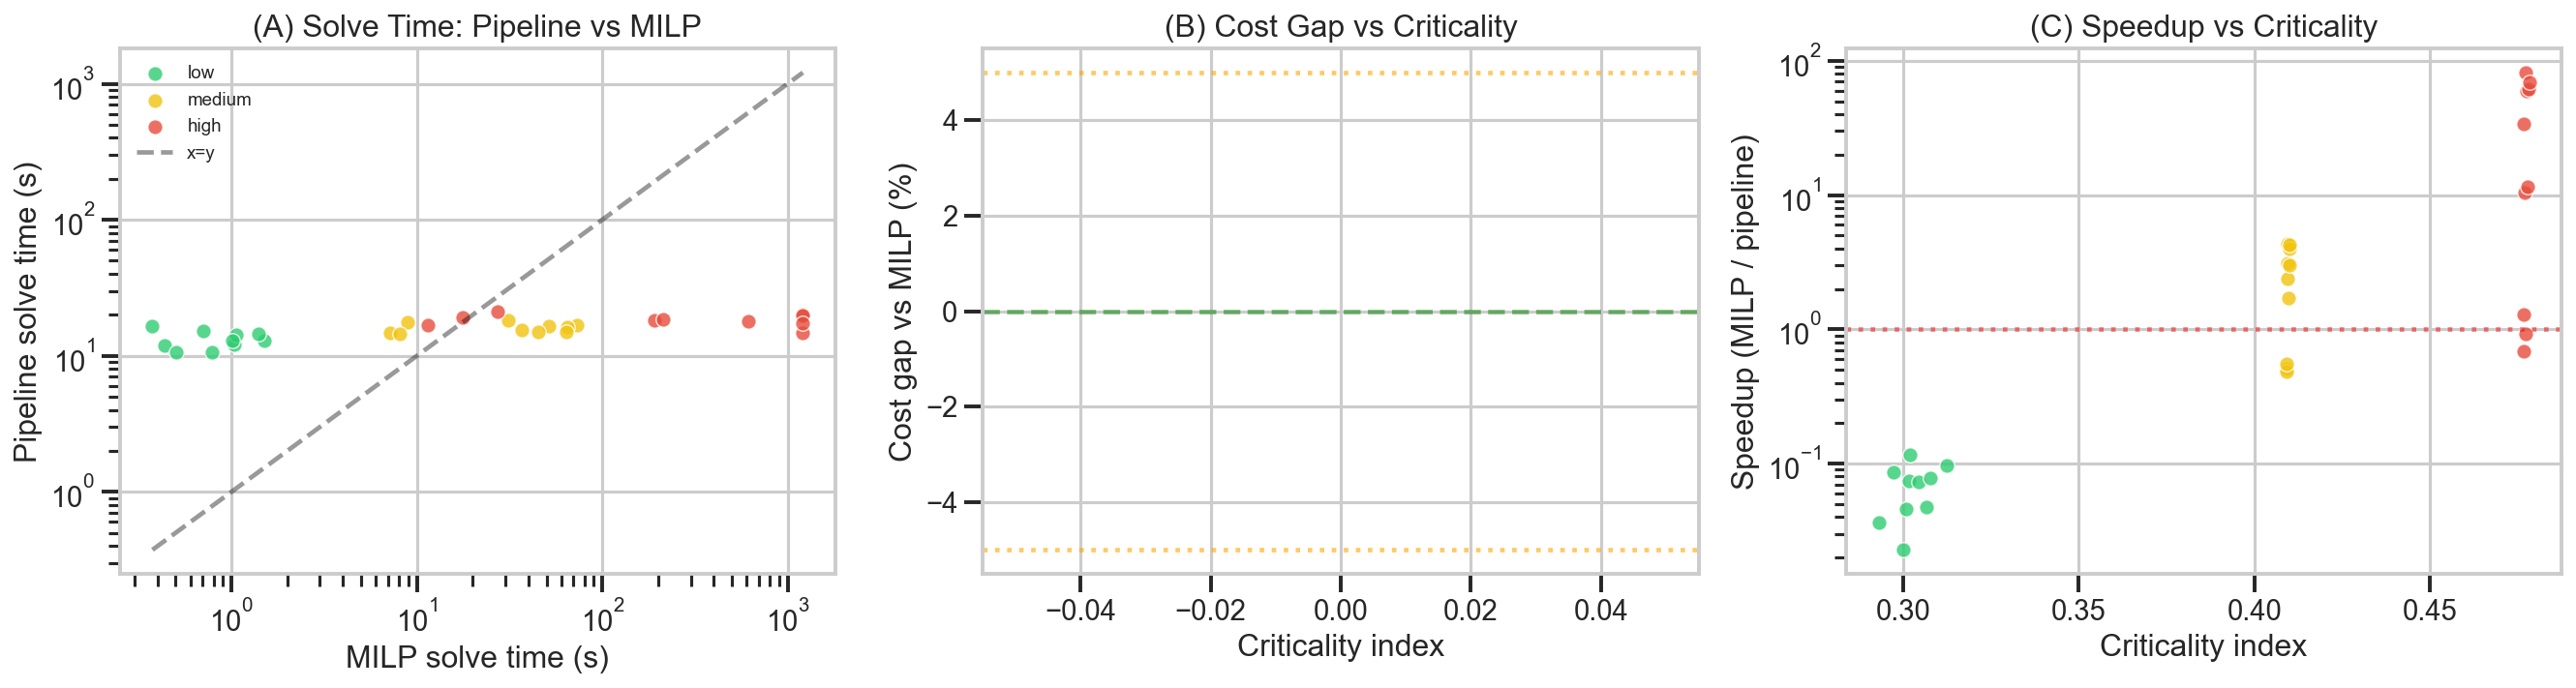

In [ ]:
speedup_mode_summary = summarize_speedup_operating_modes(df)
display(speedup_mode_summary.round(3))

if not df_k1.empty:
    true_k1_speedup_summary = summarize_speedup_operating_modes(df_k1)
    display(true_k1_speedup_summary.round(3))
else:
    true_k1_speedup_summary = pd.DataFrame()

timing_summary = (
    df.groupby('family')[[
        'pipeline_solve_time',
        'pipeline_first_candidate_time',
        'pipeline_best_candidate_oracle_time',
        'pipeline_parallel_ideal_time',
        'milp_solve_time',
        'speedup',
        'speedup_first_candidate',
        'speedup_parallel_ideal',
    ]]
    .median()
    .rename(columns={
        'pipeline_solve_time': 'pipe_wall_clock_s',
        'pipeline_first_candidate_time': 'pipe_k1_timing_view_s',
        'pipeline_best_candidate_oracle_time': 'pipe_best_oracle_s',
        'pipeline_parallel_ideal_time': 'pipe_parallel_ideal_s',
        'milp_solve_time': 'milp_s',
        'speedup': 'speedup_actual',
    })
)
display(timing_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for fam, color in FAMILY_COLORS.items():
    mask = df['family'] == fam
    ax.scatter(
        df.loc[mask, 'milp_solve_time'],
        df.loc[mask, 'pipeline_solve_time'],
        c=color,
        s=55,
        alpha=0.8,
        edgecolors='white',
        linewidth=0.7,
        label=fam,
    )
lo = max(df['milp_solve_time'].replace(0, np.nan).min(), 1e-2)
hi = max(df['milp_solve_time'].max(), df['pipeline_solve_time'].max())
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='x=y')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('MILP solve time (s)')
ax.set_ylabel('Pipeline solve time (s)')
ax.set_title('(A) Solve Time: Pipeline vs MILP')
ax.legend(fontsize=9)

ax = axes[1]
for fam, color in FAMILY_COLORS.items():
    mask = df['family'] == fam
    ax.scatter(
        df.loc[mask, 'criticality_index'],
        df.loc[mask, 'cost_gap_pct'],
        c=color,
        s=55,
        alpha=0.8,
        edgecolors='white',
        linewidth=0.7,
        label=fam,
    )
ax.axhline(0, color='green', linestyle='--', alpha=0.5)
ax.axhline(5, color='orange', linestyle=':', alpha=0.6)
ax.axhline(-5, color='orange', linestyle=':', alpha=0.6)
ax.set_xlabel('Criticality index')
ax.set_ylabel('Cost gap vs MILP (%)')
ax.set_title('(B) Cost Gap vs Criticality')

ax = axes[2]
for fam, color in FAMILY_COLORS.items():
    mask = df['family'] == fam
    ax.scatter(
        df.loc[mask, 'criticality_index'],
        df.loc[mask, 'speedup'],
        c=color,
        s=55,
        alpha=0.8,
        edgecolors='white',
        linewidth=0.7,
        label=fam,
    )
ax.axhline(1.0, color='red', linestyle=':', alpha=0.5)
ax.set_yscale('log')
ax.set_xlabel('Criticality index')
ax.set_ylabel('Speedup (MILP / pipeline)')
ax.set_title('(C) Speedup vs Criticality')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_overview_pipeline_vs_milp.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Hypothesis 1: Compute-Bounded Exploration

**Claim:** as the candidate pool size `K` grows, the best-of-`K`
candidate found by the conditioned pipeline achieves a lower cost gap.

In [ ]:
MAX_AVAILABLE_SAMPLES = max((len(rec.get('all_objectives', [])) for rec in pipeline_results), default=0)
BEST_OF_K_VALUES = [k for k in [1, 2, 3, 5, 10] if k <= MAX_AVAILABLE_SAMPLES]
if not BEST_OF_K_VALUES and MAX_AVAILABLE_SAMPLES:
    BEST_OF_K_VALUES = [MAX_AVAILABLE_SAMPLES]

candidate_pool_df = build_candidate_pool_frame(pipeline_results, df)
diversity_df = compute_solution_diversity_frame(pipeline_results, df)
bestofk_summary, bestofk_scenario = compute_best_of_k_curve(
    pipeline_results,
    df,
    k_values=BEST_OF_K_VALUES or [1],
)
kdiag_summary, kdiag_scenario = compute_k_sampling_diagnostics(
    pipeline_results,
    df,
    k_values=BEST_OF_K_VALUES or [1],
)

print(f"Max available sampled candidates per scenario: {MAX_AVAILABLE_SAMPLES}")
display(bestofk_summary.round(3))
display(kdiag_summary.round(3))

Max available sampled candidates per scenario: 0


""


""


## 10a. Candidate Selector and Top-M Policy Simulation

In [ ]:
selector_training_df = candidate_pool_df.copy()
selector_training_df = selector_training_df.replace([np.inf, -np.inf], np.nan)
selector_training_df = selector_training_df[selector_training_df['sample_idx'] < max(BEST_OF_K_VALUES or [1])].copy()

if len(selector_training_df):
    candidate_selector = fit_candidate_selector(
        selector_training_df,
        failure_penalty=None,
        time_penalty=0.05,
        test_fraction=0.25,
    )
    save_candidate_selector(candidate_selector, CANDIDATE_SELECTOR_PATH)
    print(json.dumps(candidate_selector['diagnostics'], indent=2, default=str))
    print(f"Saved candidate selector artifact to: {CANDIDATE_SELECTOR_PATH}")

    candidate_pool_scored_df = apply_candidate_selector(candidate_pool_df, candidate_selector)

    if RUN_LIVE_TOP_M_EVALUATION:
        if PIPELINE_TOP_M_RESULTS_PATH.exists() and not RUN_PIPELINE:
            live_top_m_pipeline_results = PipelineRunner.load_results(PIPELINE_TOP_M_RESULTS_PATH)
            print(f"Loaded cached live Top-M pipeline results from: {PIPELINE_TOP_M_RESULTS_PATH}")
        else:
            live_top_m_pipeline_results = run_live_top_m_evaluation()
            print(f"Saved fresh live Top-M pipeline results to: {PIPELINE_TOP_M_RESULTS_PATH}")
        live_top_m_eval_output = compute_eval_metrics(live_top_m_pipeline_results, milp_reports_dirs)
        df_live_top_m = live_top_m_eval_output['dataframe']
        print(format_metrics_table(live_top_m_eval_output['global'], f'Global live Top-M M={LIVE_TOP_M} vs MILP'))
        display(df_live_top_m.head())

    energy_scored_df = candidate_pool_df.copy()
    energy_scored_df['energy_score'] = pd.to_numeric(energy_scored_df['sample_ebm_energy'], errors='coerce')

    topm_selector_summary, topm_selector_scenario = compute_top_m_policy_curve(
        candidate_pool_scored_df,
        df,
        score_col='selector_score',
        k_values=BEST_OF_K_VALUES or [1],
        top_m_values=[1, 2, 3],
        policy_name='learned_selector_top_m',
        fallback=True,
        generate_full_k=True,
    )
    topm_energy_summary, topm_energy_scenario = compute_top_m_policy_curve(
        energy_scored_df,
        df,
        score_col='energy_score',
        k_values=BEST_OF_K_VALUES or [1],
        top_m_values=[1, 2, 3],
        policy_name='energy_top_m',
        fallback=True,
        generate_full_k=True,
    )
    topm_first_summary, topm_first_scenario = compute_top_m_policy_curve(
        candidate_pool_df,
        df,
        score_col=None,
        k_values=BEST_OF_K_VALUES or [1],
        top_m_values=[1, 2, 3],
        policy_name='first_m',
        fallback=True,
        generate_full_k=False,
    )

    topm_policy_summary = pd.concat(
        [topm_first_summary, topm_energy_summary, topm_selector_summary],
        ignore_index=True,
    )
    topm_policy_scenario = pd.concat(
        [topm_first_scenario, topm_energy_scenario, topm_selector_scenario],
        ignore_index=True,
    )
    display(topm_policy_summary.round(3))
elif CANDIDATE_SELECTOR_PATH.exists():
    candidate_selector = load_candidate_selector(CANDIDATE_SELECTOR_PATH)
    candidate_pool_scored_df = apply_candidate_selector(candidate_pool_df, candidate_selector) if len(candidate_pool_df) else candidate_pool_df.copy()
    topm_policy_summary = pd.DataFrame()
    topm_policy_scenario = pd.DataFrame()
    print(f"Loaded existing candidate selector artifact from: {CANDIDATE_SELECTOR_PATH}")
else:
    candidate_selector = None
    candidate_pool_scored_df = candidate_pool_df.copy()
    topm_policy_summary = pd.DataFrame()
    topm_policy_scenario = pd.DataFrame()
    print('Candidate pool is empty; skipping selector and Top-M policy simulation.')

KeyError: 'sample_idx'

## 10b. Optional High-Criticality Sampler Sweep

In [ ]:
sampler_sweep_configs = build_sampler_sweep_configs()
sampler_sweep_summary_rows = []
sampler_sweep_results = {}
SAMPLER_SWEEP_DIR.mkdir(parents=True, exist_ok=True)

if RUN_HIGH_CRIT_SAMPLER_SWEEP:
    for sweep_cfg in sampler_sweep_configs:
        sweep_name = sweep_cfg['name']
        sweep_path = SAMPLER_SWEEP_DIR / f'{sweep_name}.pkl'
        sweep_graph_dir = GRAPH_CACHE_ROOT / 'sampler_sweep' / sweep_name
        sweep_kwargs = {k: v for k, v in sweep_cfg.items() if k != 'name'}
        sweep_config = replace(config, **sweep_kwargs)
        sweep_runner = ConditionedPipelineRunner(sweep_config)
        sweep_runner.load_models()
        high_paths = FAMILIES['high']
        sweep_raw_results = sweep_runner.evaluate_family(
            scenarios_dir=high_paths['scenarios_dir'],
            reports_dir=high_paths['reports_dir'],
            graphs_dir=sweep_graph_dir,
            family_name='high',
            max_scenarios=MAX_SWEEP_SCENARIOS,
        )
        sweep_runner.save_results(sweep_raw_results, sweep_path)
        sweep_results = [asdict(r) for r in sweep_raw_results]
        sampler_sweep_results[sweep_name] = sweep_results
else:
    for sweep_cfg in sampler_sweep_configs:
        sweep_name = sweep_cfg['name']
        sweep_path = SAMPLER_SWEEP_DIR / f'{sweep_name}.pkl'
        if sweep_path.exists():
            sampler_sweep_results[sweep_name] = PipelineRunner.load_results(sweep_path)

for sweep_name, sweep_results in sampler_sweep_results.items():
    if not sweep_results:
        continue
    sweep_eval = compute_eval_metrics(sweep_results, {'high': FAMILIES['high']['reports_dir']}, families=['high'])
    sweep_df = sweep_eval['dataframe']
    sampler_sweep_summary_rows.append({
        'sweep': sweep_name,
        'n_scenarios': len(sweep_df),
        'success_rate_pct': float(sweep_df['success'].mean() * 100.0),
        'direct_feasible_rate_pct': float(sweep_df['pipeline_direct_feasible_rate'].mean() * 100.0),
        'repair_success_rate_pct': float(sweep_df['pipeline_repair_success_rate'].mean() * 100.0),
        'fallback_rate_pct': float(sweep_df['pipeline_fallback_used'].mean() * 100.0),
        'median_cost_gap_pct': float(sweep_df['cost_gap_pct'].median()),
        'median_abs_cost_gap_pct': float(sweep_df['cost_gap_pct'].abs().median()),
        'median_speedup': float(sweep_df['speedup'].median()),
        'median_first_candidate_speedup': float(sweep_df['speedup_first_candidate'].median()),
        'median_pipeline_time_s': float(sweep_df['pipeline_solve_time'].median()),
    })

sampler_sweep_summary = pd.DataFrame(sampler_sweep_summary_rows)
if len(sampler_sweep_summary):
    display(sampler_sweep_summary.sort_values(['fallback_rate_pct', 'median_abs_cost_gap_pct']).round(3))
else:
    print('No sampler sweep results available. Set RUN_HIGH_CRIT_SAMPLER_SWEEP=True to generate them.')

Loading HTE encoder...
  Encoder loaded: 3,185,664 params
Loading EBM checkpoint: C:\Users\coudr\OneDrive\projects\benchmark\benchmark_milp_gnn\outputs\ebm_models\final_ebm_conditioned_film\final_conditioned_ebm.pt
  Conditioned EBM loaded: 3,489,537 params
  Conditioning mode: film
  Scenario features: ['n_zones', 'criticality_index', 'demand_scale', 'peak_to_valley_ratio', 'vre_share_mean', 'vre_volatility_index', 'storage_adequacy_hours', 'dr_capacity_ratio', 'thermal_capacity_margin', 'nuclear_capacity_margin']
  Sampler ready (infer mode)

Evaluating 10 scenarios from high


Pipeline [high]:   0%|          | 0/10 [00:00<?, ?it/s]

  FAILED scenario_00001: [Errno 2] No such file or directory: 'C:\\Users\\coudr\\OneDrive\\projects\\benchmark\\benchmark_milp_gnn\\outputs\\pipeline_eval_final_conditioned\\candidate_selector.pkl'
  FAILED scenario_00002: [Errno 2] No such file or directory: 'C:\\Users\\coudr\\OneDrive\\projects\\benchmark\\benchmark_milp_gnn\\outputs\\pipeline_eval_final_conditioned\\candidate_selector.pkl'
  FAILED scenario_00003: [Errno 2] No such file or directory: 'C:\\Users\\coudr\\OneDrive\\projects\\benchmark\\benchmark_milp_gnn\\outputs\\pipeline_eval_final_conditioned\\candidate_selector.pkl'
  FAILED scenario_00004: [Errno 2] No such file or directory: 'C:\\Users\\coudr\\OneDrive\\projects\\benchmark\\benchmark_milp_gnn\\outputs\\pipeline_eval_final_conditioned\\candidate_selector.pkl'
  FAILED scenario_00005: [Errno 2] No such file or directory: 'C:\\Users\\coudr\\OneDrive\\projects\\benchmark\\benchmark_milp_gnn\\outputs\\pipeline_eval_final_conditioned\\candidate_selector.pkl'
  FAILED s

In [ ]:
from scipy.stats import friedmanchisquare, wilcoxon

if len(bestofk_scenario):
    h1_df = bestofk_scenario.copy()
    h1_df['abs_cost_gap_pct'] = h1_df['cost_gap_pct'].abs()

    gap_curve = (
        h1_df.groupby('k')
        .agg(
            mean_abs_cost_gap_pct=('abs_cost_gap_pct', 'mean'),
            median_abs_cost_gap_pct=('abs_cost_gap_pct', 'median'),
            p25_abs_cost_gap_pct=('abs_cost_gap_pct', lambda s: float(np.percentile(s.dropna(), 25)) if len(s.dropna()) else np.nan),
            p75_abs_cost_gap_pct=('abs_cost_gap_pct', lambda s: float(np.percentile(s.dropna(), 75)) if len(s.dropna()) else np.nan),
            mean_speedup_vs_milp=('speedup_vs_milp', 'mean'),
            n_scenarios=('scenario_id', 'nunique'),
        )
        .reset_index()
    )

    family_gap_curve = (
        h1_df.groupby(['family', 'k'])
        .agg(
            median_abs_cost_gap_pct=('abs_cost_gap_pct', 'median'),
            mean_abs_cost_gap_pct=('abs_cost_gap_pct', 'mean'),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax = axes[0]
    ax.plot(gap_curve['k'], gap_curve['median_abs_cost_gap_pct'], marker='o', lw=2.5, color='#1f77b4', label='Median |gap|')
    ax.plot(gap_curve['k'], gap_curve['mean_abs_cost_gap_pct'], marker='s', lw=1.8, color='#ff7f0e', label='Mean |gap|')
    ax.fill_between(
        gap_curve['k'],
        gap_curve['p25_abs_cost_gap_pct'],
        gap_curve['p75_abs_cost_gap_pct'],
        alpha=0.18,
        color='#1f77b4',
        label='IQR |gap|',
    )
    ax.set_xlabel('Candidate pool size K', fontweight='bold')
    ax.set_ylabel('Best-of-K absolute cost gap vs MILP (%)', fontweight='bold')
    ax.set_title('(A) Overall K vs Absolute Cost Gap', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    ax = axes[1]
    for fam in ['low', 'medium', 'high']:
        fam_df = family_gap_curve[family_gap_curve['family'] == fam]
        if len(fam_df) == 0:
            continue
        ax.plot(
            fam_df['k'],
            fam_df['median_abs_cost_gap_pct'],
            marker='o',
            lw=2,
            color=FAMILY_COLORS.get(fam),
            label=fam.capitalize(),
        )
    ax.set_xlabel('Candidate pool size K', fontweight='bold')
    ax.set_ylabel('Median absolute cost gap vs MILP (%)', fontweight='bold')
    ax.set_title('(B) Family-Level K Convergence', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_h1_k_vs_cost_gap.png', dpi=300, bbox_inches='tight')
    plt.show()

    h1_pivot = h1_df.pivot_table(
        index=['family', 'scenario_id'],
        columns='k',
        values='abs_cost_gap_pct',
        aggfunc='first',
    )
    h1_stats = {}
    if BEST_OF_K_VALUES:
        base_k = min(BEST_OF_K_VALUES)
        top_k = max(BEST_OF_K_VALUES)
        paired = h1_pivot[[base_k, top_k]].dropna() if base_k in h1_pivot.columns and top_k in h1_pivot.columns else pd.DataFrame()
        if len(paired) >= 2:
            w_stat, w_p = wilcoxon(
                paired[top_k],
                paired[base_k],
                alternative='less',
                zero_method='wilcox',
            )
            improvement_rate = float((paired[top_k] <= paired[base_k]).mean() * 100)
            median_delta = float((paired[base_k] - paired[top_k]).median())
            mean_delta = float((paired[base_k] - paired[top_k]).mean())
            h1_stats.update({
                'base_k': int(base_k),
                'top_k': int(top_k),
                'n_paired': int(len(paired)),
                'wilcoxon_stat': float(w_stat),
                'wilcoxon_pvalue_one_sided': float(w_p),
                'improvement_rate_pct': improvement_rate,
                'median_abs_gap_reduction_pct': median_delta,
                'mean_abs_gap_reduction_pct': mean_delta,
            })

        complete_cols = [k for k in BEST_OF_K_VALUES if k in h1_pivot.columns]
        if len(complete_cols) >= 3:
            complete = h1_pivot[complete_cols].dropna()
            if len(complete) >= 2:
                friedman_stat, friedman_p = friedmanchisquare(
                    *[complete[k].values for k in complete_cols]
                )
                h1_stats['friedman_stat'] = float(friedman_stat)
                h1_stats['friedman_pvalue'] = float(friedman_p)
                h1_stats['friedman_k_values'] = [int(k) for k in complete_cols]
                h1_stats['friedman_n_scenarios'] = int(len(complete))

    print('Hypothesis H1 diagnostics:')
    for key, value in h1_stats.items():
        print(f"  {key}: {value}")

    H1_SUPPORTED = bool(
        h1_stats.get('improvement_rate_pct', 0.0) >= 50.0
        and h1_stats.get('wilcoxon_pvalue_one_sided', 1.0) < 0.05
    )
    print(f"  Supported: {H1_SUPPORTED}")

    display(gap_curve.round(3))
else:
    H1_SUPPORTED = False
    h1_stats = {}
    print('Best-of-K scenario table is empty. Re-run with n_samples >= 2 to test Hypothesis 1.')

## 10c. Oracle Best-of-K Bottleneck Test

In [ ]:
oracle_bestofk_summary, oracle_bestofk_scenario = compute_best_of_k_curve(
    pipeline_results,
    df,
    k_values=BEST_OF_K_VALUES or [1],
    objective_field='all_objectives_raw',
)

selector_bottleneck_summary = {}
oracle_fixed_cohort_summary = pd.DataFrame()
selector_loss_curve = pd.DataFrame()

if len(oracle_bestofk_scenario):
    oracle_h1_df = oracle_bestofk_scenario.copy()
    oracle_h1_df['abs_cost_gap_pct'] = oracle_h1_df['cost_gap_pct'].abs()

    oracle_pivot = oracle_h1_df.pivot_table(
        index=['family', 'scenario_id'],
        columns='k',
        values='abs_cost_gap_pct',
        aggfunc='first',
    )
    oracle_cols = [k for k in BEST_OF_K_VALUES if k in oracle_pivot.columns]
    oracle_complete = oracle_pivot[oracle_cols].dropna() if oracle_cols else pd.DataFrame()

    oracle_fixed_rows = []
    for k in oracle_cols:
        vals = oracle_complete[k].dropna()
        oracle_fixed_rows.append({
            'k': int(k),
            'n_scenarios_fixed_cohort': int(len(vals)),
            'median_abs_cost_gap_pct': float(vals.median()) if len(vals) else np.nan,
            'mean_abs_cost_gap_pct': float(vals.mean()) if len(vals) else np.nan,
        })
    oracle_fixed_cohort_summary = pd.DataFrame(oracle_fixed_rows)

    if len(oracle_complete) and len(oracle_cols) >= 2:
        base_k = int(min(oracle_cols))
        top_k = int(max(oracle_cols))
        paired = oracle_complete[[base_k, top_k]].dropna()
        if len(paired) >= 2:
            w_stat, w_p = wilcoxon(
                paired[top_k],
                paired[base_k],
                alternative='less',
                zero_method='wilcox',
            )
            selector_bottleneck_summary = {
                'base_k': base_k,
                'top_k': top_k,
                'n_paired': int(len(paired)),
                'strict_h1_improvement_rate_pct': float(globals().get('h1_stats', {}).get('improvement_rate_pct', np.nan)),
                'strict_h1_median_abs_gap_reduction_pct': float(globals().get('h1_stats', {}).get('median_abs_gap_reduction_pct', np.nan)),
                'oracle_improvement_rate_pct': float((paired[top_k] <= paired[base_k]).mean() * 100.0),
                'oracle_median_abs_gap_reduction_pct': float((paired[base_k] - paired[top_k]).median()),
                'oracle_mean_abs_gap_reduction_pct': float((paired[base_k] - paired[top_k]).mean()),
                'oracle_wilcoxon_stat': float(w_stat),
                'oracle_wilcoxon_pvalue_one_sided': float(w_p),
                'oracle_fixed_cohort_k_values': [int(k) for k in oracle_cols],
            }

    if len(bestofk_summary) and len(oracle_bestofk_summary):
        selector_loss_curve = bestofk_summary[
            ['k', 'median_abs_cost_gap_pct', 'mean_abs_cost_gap_pct']
        ].merge(
            oracle_bestofk_summary[
                ['k', 'median_abs_cost_gap_pct', 'mean_abs_cost_gap_pct']
            ],
            on='k',
            how='inner',
            suffixes=('_strict', '_oracle'),
        )
        if len(selector_loss_curve):
            selector_loss_curve['median_abs_gap_selector_loss_pct'] = (
                selector_loss_curve['median_abs_cost_gap_pct_strict']
                - selector_loss_curve['median_abs_cost_gap_pct_oracle']
            )
            selector_loss_curve['mean_abs_gap_selector_loss_pct'] = (
                selector_loss_curve['mean_abs_cost_gap_pct_strict']
                - selector_loss_curve['mean_abs_cost_gap_pct_oracle']
            )
            if selector_bottleneck_summary:
                top_k_match = selector_loss_curve[selector_loss_curve['k'] == selector_bottleneck_summary.get('top_k')]
                if len(top_k_match):
                    selector_bottleneck_summary['selector_loss_median_abs_gap_pct_at_top_k'] = float(
                        top_k_match['median_abs_gap_selector_loss_pct'].iloc[0]
                    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax = axes[0]
    if len(bestofk_summary):
        ax.plot(
            bestofk_summary['k'],
            bestofk_summary['median_abs_cost_gap_pct'],
            marker='o',
            lw=2.2,
            color='#e67e22',
            label='Strict accepted candidates',
        )
    if len(oracle_bestofk_summary):
        ax.plot(
            oracle_bestofk_summary['k'],
            oracle_bestofk_summary['median_abs_cost_gap_pct'],
            marker='s',
            lw=2.2,
            color='#1f77b4',
            label='Oracle ex post (raw projection cost)',
        )
    ax.set_xlabel('Candidate pool size K', fontweight='bold')
    ax.set_ylabel('Median absolute cost gap (%)', fontweight='bold')
    ax.set_title('(A) Aggregate Strict vs Oracle Curves', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    ax = axes[1]
    if len(oracle_fixed_cohort_summary):
        ax.plot(
            oracle_fixed_cohort_summary['k'],
            oracle_fixed_cohort_summary['median_abs_cost_gap_pct'],
            marker='o',
            lw=2.4,
            color='#1f77b4',
            label='Oracle fixed cohort',
        )
    if len(BEST_OF_K_VALUES) and globals().get('h1_stats', {}).get('base_k') is not None:
        strict_pivot = globals().get('h1_pivot', pd.DataFrame())
        strict_cols = [k for k in BEST_OF_K_VALUES if isinstance(strict_pivot, pd.DataFrame) and k in strict_pivot.columns]
        if strict_cols:
            strict_complete = strict_pivot[strict_cols].dropna()
            if len(strict_complete):
                strict_fixed_rows = []
                for k in strict_cols:
                    vals = strict_complete[k].dropna()
                    strict_fixed_rows.append({
                        'k': int(k),
                        'median_abs_cost_gap_pct': float(vals.median()) if len(vals) else np.nan,
                    })
                strict_fixed_df = pd.DataFrame(strict_fixed_rows)
                ax.plot(
                    strict_fixed_df['k'],
                    strict_fixed_df['median_abs_cost_gap_pct'],
                    marker='s',
                    lw=2.2,
                    color='#e67e22',
                    label='Strict fixed cohort',
                )
    ax.set_xlabel('Candidate pool size K', fontweight='bold')
    ax.set_ylabel('Median absolute cost gap (%)', fontweight='bold')
    ax.set_title('(B) Fixed-Cohort Bottleneck Test', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_h1_oracle_selector_bottleneck.png', dpi=300, bbox_inches='tight')
    plt.show()

    display(oracle_bestofk_summary.round(3))
    display(oracle_fixed_cohort_summary.round(3))
    if len(selector_loss_curve):
        display(selector_loss_curve.round(3))

    print('Selector bottleneck diagnostics:')
    for key, value in selector_bottleneck_summary.items():
        print(f"  {key}: {value}")
else:
    print('Oracle best-of-K table is empty. Re-run with cached raw candidate objectives.')

## 10d. Projection and Repair Diagnostics

In [ ]:
def _flatten_numeric_lists(series):
    values = []
    for item in series:
        if item is None:
            continue
        if isinstance(item, float) and np.isnan(item):
            continue
        if not isinstance(item, (list, tuple, np.ndarray)):
            continue
        for value in item:
            try:
                value_f = float(value)
            except (TypeError, ValueError):
                continue
            if np.isfinite(value_f):
                values.append(value_f)
    return values


def _projection_diag_row(name: str, sub_df: pd.DataFrame, family_key=None) -> dict:
    total_samples = float(sub_df['n_samples'].sum()) if 'n_samples' in sub_df.columns else 0.0
    total_direct = float(sub_df['pipeline_direct_feasible_count'].sum()) if 'pipeline_direct_feasible_count' in sub_df.columns else 0.0
    total_repaired = float(sub_df['pipeline_repaired_feasible_count'].sum()) if 'pipeline_repaired_feasible_count' in sub_df.columns else 0.0
    repair_attempts = max(total_samples - total_direct, 0.0)

    repair_flips = _flatten_numeric_lists(sub_df['pipeline_all_repair_flips']) if 'pipeline_all_repair_flips' in sub_df.columns else []
    repair_radii = _flatten_numeric_lists(sub_df['pipeline_all_repair_radii']) if 'pipeline_all_repair_radii' in sub_df.columns else []
    repair_times = _flatten_numeric_lists(sub_df['pipeline_all_repair_times']) if 'pipeline_all_repair_times' in sub_df.columns else []

    repaired_selected = (
        sub_df[sub_df['pipeline_best_status'] == 'repaired_feasible'].copy()
        if 'pipeline_best_status' in sub_df.columns
        else sub_df.iloc[0:0].copy()
    )

    k_min = np.nan
    k_max = np.nan
    k1_gap = np.nan
    ktop_gap = np.nan
    k1_abs_gap = np.nan
    ktop_abs_gap = np.nan
    if len(bestofk_scenario):
        bestofk_scope = bestofk_scenario if family_key is None else bestofk_scenario[bestofk_scenario['family'] == family_key]
        if len(bestofk_scope):
            k_min = int(bestofk_scope['k'].min())
            k_max = int(bestofk_scope['k'].max())
            k1_gap = float(bestofk_scope.loc[bestofk_scope['k'] == k_min, 'cost_gap_pct'].median())
            ktop_gap = float(bestofk_scope.loc[bestofk_scope['k'] == k_max, 'cost_gap_pct'].median())
            k1_abs_gap = float(bestofk_scope.loc[bestofk_scope['k'] == k_min, 'cost_gap_pct'].abs().median())
            ktop_abs_gap = float(bestofk_scope.loc[bestofk_scope['k'] == k_max, 'cost_gap_pct'].abs().median())

    return {
        'Family': name,
        'N scenarios': int(len(sub_df)),
        'direct_feasible_rate_pct': float(100.0 * total_direct / total_samples) if total_samples > 0 else np.nan,
        'repair_success_rate_pct': float(100.0 * total_repaired / repair_attempts) if repair_attempts > 0 else np.nan,
        'fallback_rate_pct': float(sub_df['pipeline_fallback_used'].mean() * 100.0) if len(sub_df) else np.nan,
        'mean_repair_flips': float(np.mean(repair_flips)) if repair_flips else np.nan,
        'median_repair_flips': float(np.median(repair_flips)) if repair_flips else np.nan,
        'median_repair_radius_used': float(np.median(repair_radii)) if repair_radii else np.nan,
        'median_repair_time_s': float(np.median(repair_times)) if repair_times else np.nan,
        'best_of_K_gap_pct_median': float(sub_df['cost_gap_pct'].median()) if len(sub_df) else np.nan,
        'best_of_K_abs_gap_pct_median': float(sub_df['cost_gap_pct'].abs().median()) if len(sub_df) else np.nan,
        'gap_k_min': k_min,
        'gap_k_max': k_max,
        'gap_pct_at_k_min_median': k1_gap,
        'gap_pct_at_k_max_median': ktop_gap,
        'abs_gap_pct_at_k_min_median': k1_abs_gap,
        'abs_gap_pct_at_k_max_median': ktop_abs_gap,
        'abs_gap_reduction_kmin_to_kmax_pct': float(k1_abs_gap - ktop_abs_gap) if np.isfinite(k1_abs_gap) and np.isfinite(ktop_abs_gap) else np.nan,
        'selected_repaired_flips_median': float(repaired_selected['pipeline_selected_repair_flips'].median()) if len(repaired_selected) and 'pipeline_selected_repair_flips' in repaired_selected.columns else np.nan,
        'selected_repaired_radius_median': float(repaired_selected['pipeline_selected_repair_radius_used'].median()) if len(repaired_selected) and 'pipeline_selected_repair_radius_used' in repaired_selected.columns else np.nan,
        'selected_repaired_time_median_s': float(repaired_selected['pipeline_selected_repair_time'].median()) if len(repaired_selected) and 'pipeline_selected_repair_time' in repaired_selected.columns else np.nan,
    }


projection_diag_rows = [_projection_diag_row('ALL', df, family_key=None)]
for fam in ['low', 'medium', 'high']:
    fam_df = df[df['family'] == fam].copy()
    if len(fam_df):
        projection_diag_rows.append(_projection_diag_row(fam.capitalize(), fam_df, family_key=fam))

projection_diagnostics_df = pd.DataFrame(projection_diag_rows)
display(projection_diagnostics_df.round(3))

projection_status_counts = (
    df['pipeline_best_status'].value_counts(dropna=False).to_dict()
    if 'pipeline_best_status' in df.columns
    else {}
)
high_gap_row = projection_diagnostics_df[projection_diagnostics_df['Family'] == 'High']
high_criticality_gap = (
    float(high_gap_row['best_of_K_gap_pct_median'].iloc[0])
    if len(high_gap_row)
    else np.nan
)

projection_diagnostics_summary = {
    'best_status_distribution': projection_status_counts,
    'overall_direct_feasible_rate_pct': float(projection_diagnostics_df.loc[projection_diagnostics_df['Family'] == 'ALL', 'direct_feasible_rate_pct'].iloc[0]),
    'overall_repair_success_rate_pct': float(projection_diagnostics_df.loc[projection_diagnostics_df['Family'] == 'ALL', 'repair_success_rate_pct'].iloc[0]),
    'overall_fallback_rate_pct': float(projection_diagnostics_df.loc[projection_diagnostics_df['Family'] == 'ALL', 'fallback_rate_pct'].iloc[0]),
    'overall_mean_repair_flips': float(projection_diagnostics_df.loc[projection_diagnostics_df['Family'] == 'ALL', 'mean_repair_flips'].iloc[0]),
    'overall_median_repair_flips': float(projection_diagnostics_df.loc[projection_diagnostics_df['Family'] == 'ALL', 'median_repair_flips'].iloc[0]),
    'overall_best_of_K_gap_pct_median': float(projection_diagnostics_df.loc[projection_diagnostics_df['Family'] == 'ALL', 'best_of_K_gap_pct_median'].iloc[0]),
    'overall_abs_gap_reduction_kmin_to_kmax_pct': float(projection_diagnostics_df.loc[projection_diagnostics_df['Family'] == 'ALL', 'abs_gap_reduction_kmin_to_kmax_pct'].iloc[0]),
    'high_criticality_gap_pct_median': high_criticality_gap,
}

print('Projection / repair diagnostics:')
for key, value in projection_diagnostics_summary.items():
    print(f"  {key}: {value}")

## 11. Hypothesis 2: Scaling with Criticality

**Claim:** the pipeline speedup relative to MILP increases with the
scenario criticality index.

In [ ]:
physical_feature_df = build_physical_complexity_frame(
    {name: paths['scenarios_dir'] for name, paths in FAMILIES.items()},
    cache_path=OUTPUT_DIR / 'physical_complexity_features.csv',
)
df_scaling = merge_physical_complexity_features(df, physical_feature_df)
scaling_models = fit_scaling_law_models(
    df_scaling,
    feature_col='criticality_index',
    cost_gap_col='cost_gap_pct',
    use_abs_gap=True,
)
physical_robustness_df = fit_physical_feature_robustness(
    df_scaling,
    feature_cols=PHYSICAL_FEATURE_COLUMNS,
    cost_gap_col='cost_gap_pct',
    use_abs_gap=True,
)

valid_speed = (
    df_scaling[['criticality_index', 'speedup', 'cost_gap_pct', 'family']]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=['criticality_index', 'speedup'])
)
valid_speed = valid_speed[valid_speed['speedup'] > 0]

rho_speed, p_speed = stats.spearmanr(valid_speed['criticality_index'], valid_speed['speedup'], nan_policy='omit')
lin_speed = stats.linregress(valid_speed['criticality_index'], np.log(valid_speed['speedup']))

crit_q10, crit_q90 = np.percentile(valid_speed['criticality_index'], [10, 90])
pred_speed_q10 = float(np.exp(lin_speed.intercept + lin_speed.slope * crit_q10))
pred_speed_q90 = float(np.exp(lin_speed.intercept + lin_speed.slope * crit_q90))

h2_stats = {
    'spearman_rho_speedup_vs_criticality': float(rho_speed),
    'spearman_pvalue': float(p_speed),
    'loglinear_slope': float(lin_speed.slope),
    'loglinear_rvalue': float(lin_speed.rvalue),
    'loglinear_pvalue': float(lin_speed.pvalue),
    'pred_speedup_at_q10_criticality': pred_speed_q10,
    'pred_speedup_at_q90_criticality': pred_speed_q90,
    'pred_speedup_ratio_q90_over_q10': float(pred_speed_q90 / max(pred_speed_q10, 1e-9)),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for fam in ['low', 'medium', 'high']:
    sub = valid_speed[valid_speed['family'] == fam]
    ax.scatter(
        sub['criticality_index'],
        sub['speedup'],
        c=FAMILY_COLORS[fam],
        s=55,
        alpha=0.8,
        edgecolors='white',
        linewidth=0.7,
        label=fam.capitalize(),
    )
x_line = np.linspace(valid_speed['criticality_index'].min(), valid_speed['criticality_index'].max(), 200)
y_line = np.exp(lin_speed.intercept + lin_speed.slope * x_line)
ax.plot(x_line, y_line, 'k--', lw=2, alpha=0.75, label=f"Spearman rho={rho_speed:.2f}")
ax.axhline(1.0, color='red', linestyle=':', alpha=0.5)
ax.set_yscale('log')
ax.set_xlabel('Criticality index', fontweight='bold')
ax.set_ylabel('Speedup (MILP / pipeline)', fontweight='bold')
ax.set_title('(A) Speedup vs Criticality', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
family_speedup = (
    valid_speed.groupby('family')['speedup']
    .agg(['median', 'mean', 'count'])
    .reindex(['low', 'medium', 'high'])
)
ax.bar(
    family_speedup.index,
    family_speedup['median'],
    color=[FAMILY_COLORS[f] for f in family_speedup.index],
    alpha=0.85,
)
ax.axhline(1.0, color='red', linestyle=':', alpha=0.5)
ax.set_yscale('log')
ax.set_ylabel('Median speedup', fontweight='bold')
ax.set_title('(B) Speedup by Criticality Family', fontweight='bold')

ax = axes[2]
if scaling_models:
    points = scaling_models['panel_b_points']
    fit = scaling_models['panel_b_fit']
    ax.scatter(
        points['criticality_index'],
        points['pipeline_faster'],
        s=20,
        alpha=0.35,
        color='#34495e',
        label='Scenario outcome',
    )
    if len(fit):
        ax.plot(
            fit['criticality_index'],
            fit['prob_pipeline_faster'],
            color='#1f77b4',
            lw=2.5,
            label='Logistic fit',
        )
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Criticality index', fontweight='bold')
    ax.set_ylabel('P(speedup > 1)', fontweight='bold')
    ax.set_title('(C) Probability Pipeline is Faster', fontweight='bold')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'Scaling model unavailable', ha='center', va='center')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_h2_speedup_vs_criticality.png', dpi=300, bbox_inches='tight')
plt.show()

print('Hypothesis H2 diagnostics:')
for key, value in h2_stats.items():
    print(f"  {key}: {value}")

H2_SUPPORTED = bool(rho_speed > 0 and p_speed < 0.05)
print(f"  Supported: {H2_SUPPORTED}")

display(physical_robustness_df.round(4))

## 12. Stage Distribution and Timing Breakdown

In [ ]:
stages = PIPELINE_STAGE_ORDER
families_list = ['low', 'medium', 'high']

def _stage_pcts(sub_df: pd.DataFrame, stage_col: str) -> List[Dict[str, float]]:
    pcts = []
    for fam in families_list:
        fam_df = sub_df[sub_df['family'] == fam]
        counts = fam_df[stage_col].fillna('').value_counts() if stage_col in fam_df.columns else pd.Series(dtype=float)
        pcts.append({s: counts.get(s, 0) / max(len(fam_df), 1) * 100 for s in stages})
    return pcts

def _plot_stage_bar(ax, pcts, title):
    x = np.arange(len(families_list))
    bottom = np.zeros(len(families_list))
    for stage in stages:
        vals = np.array([p[stage] for p in pcts])
        ax.bar(
            x,
            vals,
            0.65,
            bottom=bottom,
            label=stage,
            color=STAGE_COLORS.get(stage, 'gray'),
            alpha=0.9,
            edgecolor='white',
            linewidth=0.6,
        )
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(['Low', 'Medium', 'High'])
    ax.set_ylabel('Share of scenarios (%)')
    ax.set_ylim(0, 105)
    ax.set_title(title)

pipe_stage_col = 'pipeline_stage_reached' if 'pipeline_stage_reached' in df.columns else 'pipeline_stage'
pipe_pcts = _stage_pcts(df, pipe_stage_col)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_plot_stage_bar(axes[0], pipe_pcts, '(A) Deepest LP Stage Reached')
axes[0].legend(fontsize=8, ncol=2)

timing_cols = [
    'time_graph_build',
    'time_embedding',
    'time_ebm_sampling',
    'time_decoder',
    'time_lp_solve',
]
timing_by_family = df.groupby('family')[timing_cols].mean().reindex(families_list)
timing_by_family.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=['#95a5a6', '#3498db', '#9b59b6', '#f39c12', '#e74c3c'],
    alpha=0.9,
)
axes[1].set_ylabel('Mean time (s)')
axes[1].set_title('(B) Mean Timing Breakdown')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_stage_distribution_timing_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

display(timing_by_family.round(2))

## 13. Final Summary and Save Outputs

In [ ]:
families_list = ['low', 'medium', 'high']
PIPE_STAGE_COL = 'pipeline_stage_reached' if 'pipeline_stage_reached' in df.columns else 'pipeline_stage'

def _stage_reached_pct(sub_df, reached_col, fallback_stage_col, stage_name, include_later=False):
    if reached_col in sub_df.columns:
        return sub_df[reached_col].fillna(False).astype(bool).mean() * 100
    if fallback_stage_col in sub_df.columns:
        if include_later and stage_name == 'full_soft':
            return sub_df[fallback_stage_col].isin(['full_soft', 'round_refix']).mean() * 100
        return (sub_df[fallback_stage_col] == stage_name).mean() * 100
    return 0.0

def _build_row(name, sub_df):
    valid_p = sub_df.dropna(subset=['speedup', 'cost_gap_pct'])
    row = {
        'Family': name,
        'N': len(sub_df),
        'Criticality Mean': float(sub_df['criticality_index'].mean()),
        'Pipeline Success %': float(sub_df['success'].mean() * 100),
        'Pipeline Speedup Median x': float(valid_p['speedup'].median()) if len(valid_p) else np.nan,
        'Pipeline First-Candidate Speedup Median x': float(valid_p['speedup_first_candidate'].median()) if 'speedup_first_candidate' in valid_p.columns and len(valid_p) else np.nan,
        'Pipeline Parallel-Ideal Speedup Median x': float(valid_p['speedup_parallel_ideal'].median()) if 'speedup_parallel_ideal' in valid_p.columns and len(valid_p) else np.nan,
        'Pipeline Speedup Mean x': float(valid_p['speedup'].mean()) if len(valid_p) else np.nan,
        'Pipeline Gap P50 %': float(valid_p['cost_gap_pct'].median()) if len(valid_p) else np.nan,
        'Pipeline Gap P90 %': float(np.percentile(valid_p['cost_gap_pct'], 90)) if len(valid_p) else np.nan,
        'Pipeline Gap P99 %': float(np.percentile(valid_p['cost_gap_pct'], 99)) if len(valid_p) else np.nan,
        'Pipeline Time Mean s': float(sub_df['pipeline_solve_time'].mean()),
        'Pipeline S4 reached %': float(_stage_reached_pct(sub_df, 'pipeline_reached_full_soft', PIPE_STAGE_COL, 'full_soft', include_later=True)),
        'Pipeline S5 reached %': float(_stage_reached_pct(sub_df, 'pipeline_reached_round_refix', PIPE_STAGE_COL, 'round_refix')),
    }
    if globals().get('HAS_HEURISTIC', False) and 'heur_speedup' in sub_df.columns:
        valid_h = sub_df.dropna(subset=['heur_speedup', 'heur_cost_gap_pct'])
        row.update({
            'Heuristic Speedup Median x': float(valid_h['heur_speedup'].median()) if len(valid_h) else np.nan,
            'Heuristic Gap P50 %': float(valid_h['heur_cost_gap_pct'].median()) if len(valid_h) else np.nan,
        })
    return row

summary_rows = [_build_row(fam.capitalize(), df[df['family'] == fam]) for fam in families_list]
summary_rows.append(_build_row('ALL', df))
summary_table = pd.DataFrame(summary_rows)
display(summary_table.round(3))

hypothesis_summary = {
    'hypothesis_h1_compute_bounded_exploration_supported': bool(globals().get('H1_SUPPORTED', False)),
    'hypothesis_h2_speedup_scales_with_criticality_supported': bool(globals().get('H2_SUPPORTED', False)),
    'h1_stats': globals().get('h1_stats', {}),
    'selector_bottleneck_summary': globals().get('selector_bottleneck_summary', {}),
    'candidate_selector_diagnostics': candidate_selector.get('diagnostics', {}) if globals().get('candidate_selector') else {},
    'top_m_policy_summary': topm_policy_summary.to_dict(orient='records') if globals().get('topm_policy_summary') is not None and len(topm_policy_summary) else [],
    'sampler_sweep_summary': sampler_sweep_summary.to_dict(orient='records') if globals().get('sampler_sweep_summary') is not None and len(sampler_sweep_summary) else [],
    'live_top_m_config': {
        'enabled': bool(RUN_LIVE_TOP_M_EVALUATION or len(df_live_top_m) > 0),
        'top_m': int(LIVE_TOP_M),
        'score_mode': str(LIVE_TOP_M_SCORE_MODE),
        'target_activation_rate': LIVE_TOP_M_TARGET_ACTIVATION_RATE,
        'energy_weight': float(LIVE_TOP_M_ENERGY_WEIGHT),
        'activation_weight': float(LIVE_TOP_M_ACTIVATION_WEIGHT),
    },
    'h2_stats': globals().get('h2_stats', {}),
    'projection_diagnostics_summary': globals().get('projection_diagnostics_summary', {}),
    'scaling_law_summary': scaling_models.get('summary', {}) if globals().get('scaling_models') else {},
}

summary_table.to_csv(OUTPUT_DIR / 'summary_table.csv', index=False)
df.to_csv(OUTPUT_DIR / 'full_comparison.csv', index=False)
if not df_k1.empty:
    df_k1.to_csv(OUTPUT_DIR / 'full_comparison_k1_true_rerun.csv', index=False)
if not df_live_top_m.empty:
    df_live_top_m.to_csv(OUTPUT_DIR / f'full_comparison_{LIVE_TOP_M_CACHE_STEM}.csv', index=False)
if 'speedup_mode_summary' in globals() and len(speedup_mode_summary):
    speedup_mode_summary.to_csv(OUTPUT_DIR / 'speedup_operating_modes.csv', index=False)
if 'true_k1_speedup_summary' in globals() and len(true_k1_speedup_summary):
    true_k1_speedup_summary.to_csv(OUTPUT_DIR / 'speedup_operating_modes_k1_true_rerun.csv', index=False)
candidate_pool_df.to_csv(OUTPUT_DIR / 'candidate_pool_samples.csv', index=False)
if 'candidate_pool_scored_df' in globals() and len(candidate_pool_scored_df):
    candidate_pool_scored_df.to_csv(OUTPUT_DIR / 'candidate_pool_samples_scored.csv', index=False)
diversity_df.to_csv(OUTPUT_DIR / 'solution_diversity.csv', index=False)
if 'topm_policy_summary' in globals() and len(topm_policy_summary):
    topm_policy_summary.to_csv(OUTPUT_DIR / 'top_m_policy_summary.csv', index=False)
if 'topm_policy_scenario' in globals() and len(topm_policy_scenario):
    topm_policy_scenario.to_csv(OUTPUT_DIR / 'top_m_policy_per_scenario.csv', index=False)
if 'sampler_sweep_summary' in globals() and len(sampler_sweep_summary):
    sampler_sweep_summary.to_csv(OUTPUT_DIR / 'high_criticality_sampler_sweep_summary.csv', index=False)
if 'projection_diagnostics_df' in globals() and len(projection_diagnostics_df):
    projection_diagnostics_df.to_csv(OUTPUT_DIR / 'projection_diagnostics_summary.csv', index=False)
if len(bestofk_summary):
    bestofk_summary.to_csv(OUTPUT_DIR / 'best_of_k_summary.csv', index=False)
if len(bestofk_scenario):
    bestofk_scenario.to_csv(OUTPUT_DIR / 'best_of_k_per_scenario.csv', index=False)
if 'oracle_bestofk_summary' in globals() and len(oracle_bestofk_summary):
    oracle_bestofk_summary.to_csv(OUTPUT_DIR / 'oracle_best_of_k_summary.csv', index=False)
if 'oracle_bestofk_scenario' in globals() and len(oracle_bestofk_scenario):
    oracle_bestofk_scenario.to_csv(OUTPUT_DIR / 'oracle_best_of_k_per_scenario.csv', index=False)
if 'oracle_fixed_cohort_summary' in globals() and len(oracle_fixed_cohort_summary):
    oracle_fixed_cohort_summary.to_csv(OUTPUT_DIR / 'oracle_best_of_k_fixed_cohort_summary.csv', index=False)
if 'selector_loss_curve' in globals() and len(selector_loss_curve):
    selector_loss_curve.to_csv(OUTPUT_DIR / 'selector_loss_curve.csv', index=False)
if len(kdiag_summary):
    kdiag_summary.to_csv(OUTPUT_DIR / 'k_sampling_diagnostics_summary.csv', index=False)
if len(kdiag_scenario):
    kdiag_scenario.to_csv(OUTPUT_DIR / 'k_sampling_diagnostics_per_scenario.csv', index=False)
if 'df_scaling' in globals():
    df_scaling.to_csv(OUTPUT_DIR / 'full_comparison_with_physical_features.csv', index=False)
if 'physical_robustness_df' in globals() and len(physical_robustness_df):
    physical_robustness_df.to_csv(OUTPUT_DIR / 'physical_feature_robustness.csv', index=False)

with open(OUTPUT_DIR / 'hypothesis_summary.json', 'w', encoding='utf-8') as f:
    json.dump(hypothesis_summary, f, indent=2, default=str)
with open(OUTPUT_DIR / 'eval_metrics.json', 'w', encoding='utf-8') as f:
    json.dump({k: v for k, v in eval_output.items() if k != 'dataframe'}, f, indent=2, default=str)
if k1_eval_output is not None:
    with open(OUTPUT_DIR / 'eval_metrics_k1_true_rerun.json', 'w', encoding='utf-8') as f:
        json.dump({k: v for k, v in k1_eval_output.items() if k != 'dataframe'}, f, indent=2, default=str)
if live_top_m_eval_output is not None:
    with open(OUTPUT_DIR / f'eval_metrics_{LIVE_TOP_M_CACHE_STEM}.json', 'w', encoding='utf-8') as f:
        json.dump({k: v for k, v in live_top_m_eval_output.items() if k != 'dataframe'}, f, indent=2, default=str)

print(f"Saved outputs to: {OUTPUT_DIR}")
for path in sorted(OUTPUT_DIR.iterdir()):
    size_kb = path.stat().st_size / 1024
    print(f"  {path.name:45s} {size_kb:9.1f} KB")

print("\nHypothesis verdicts:")
print(f"  H1 - cost gap decreases with K: {globals().get('H1_SUPPORTED', False)}")
print(f"  H2 - speedup increases with criticality: {globals().get('H2_SUPPORTED', False)}")